# JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm
*Author: Debabrata Adhikari (<debaa@dtu.dk>)*

This notebook reads the TXM data format.

The ```structure-tensor``` package we will be using here is a 2D and 3D strcture tensor package for Python implemented by [Vedrana A. Dahl](mailto:vand@dtu.dk) and [Niels Jeppesen](mailto:niejep@dtu.dk).

JSON file in relation to DREAM3D slices will be written with fiber classes implemented by [Debabrata Adhikari](debaa@dtu.dk).

In [1]:
import time
start_time = time.time()

In [2]:
import dxchange
print(dxchange.__version__)
print(dir(dxchange))

spefile module not found
netCDF4 module not found
EdfFile module not found


0.1.8
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'absolute_import', 'division', 'dtype', 'exchange', 'logging', 'pkg_resources', 'print_function', 'read_als_832', 'read_als_832h5', 'read_anka_topotomo', 'read_aps_13bm', 'read_aps_13id', 'read_aps_1id', 'read_aps_1id_metafile', 'read_aps_26id', 'read_aps_2bm', 'read_aps_32id', 'read_aps_5bm', 'read_aps_7bm', 'read_aps_8bm', 'read_aps_tomoscan_hdf5', 'read_aus_microct', 'read_diamond_l12', 'read_edf', 'read_elettra_syrmep', 'read_esrf_id19', 'read_file_list', 'read_fits', 'read_hdf5', 'read_hdf5_stack', 'read_hdf_meta', 'read_lnls_imx', 'read_netcdf4', 'read_nexus', 'read_npy', 'read_nsls2_fxi18_h5', 'read_petraIII_p05', 'read_sls_tomcat', 'read_spe', 'read_tiff', 'read_tiff_stack', 'read_txrm', 'read_xrm', 'read_xrm_stack', 'reader', 'sys', 'unicode_literals', 'warnings', 'write_aps_1id_report', 'write_dxf', 'write_hdf5', 'write_netcdf4', 'write_n

Install dxchange, structure_tesor and other dependencies. Install Ole using pip, if it shows missing after installation of dxchange.

In [3]:
import os
from multiprocessing import Pool

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import dxchange
from dxchange import reader
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from scipy import ndimage
from scipy.spatial.transform import Rotation as R
from skimage import filters
from structure_tensor import eig_special_3d, structure_tensor_3d
from tqdm import tqdm
import shutil
import pathlib

from structure_tensor_workers import calculate_angles, get_crops, init_worker, structure_tensor_analysis_v1
from read_and_update_json import read_and_update_json_dream3d as jesonDream3d


## Load and display data
First, we'll load a sample of the data and some meta data. We will be using the following folder structure:
- ```./notebooks``` contains the notebooks.
- ```./originals``` should contain the original data files.
- ```./tmp``` should contain any temperary files or output we create.
- ```./notebooks/figures/<file_name>``` contains optionally saved figures.

In [4]:
# Set file name and path.
file_name = 'JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm'
file_path = os.path.join('./', file_name)

In [5]:
print(file_path)

./JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm


In [6]:
# Change this to True to save figures to folder.
save_figures = True

# Create folder for to save figures.
fig_path = os.path.join('./figures', os.path.basename(file_name) + '-l2')
if save_figures and fig_path and not os.path.exists(fig_path):
    os.makedirs(fig_path)

In [7]:
# Read the first slice and metadata.
# data = dxchange.read_tiff_stack(file_path, slice_range=(1, None, None))
sample, meta = reader.read_txrm(file_path, slice_range=(1, None, None))

data_shape = (meta['number_of_images'], meta['image_height'], meta['image_width'])
data_type = sample.dtype
voxel_size = meta['pixel_size']
fiber_diameter = 17

print('Shape:', data_shape)
print('Data type:', data_type)
print('Voxel size:', voxel_size, 'μm')
print('Fiber diameter size:', fiber_diameter, 'μm')

Shape: (1011, 1024, 1000)
Data type: uint16
Voxel size: 13.966073036193848 μm
Fiber diameter size: 17 μm


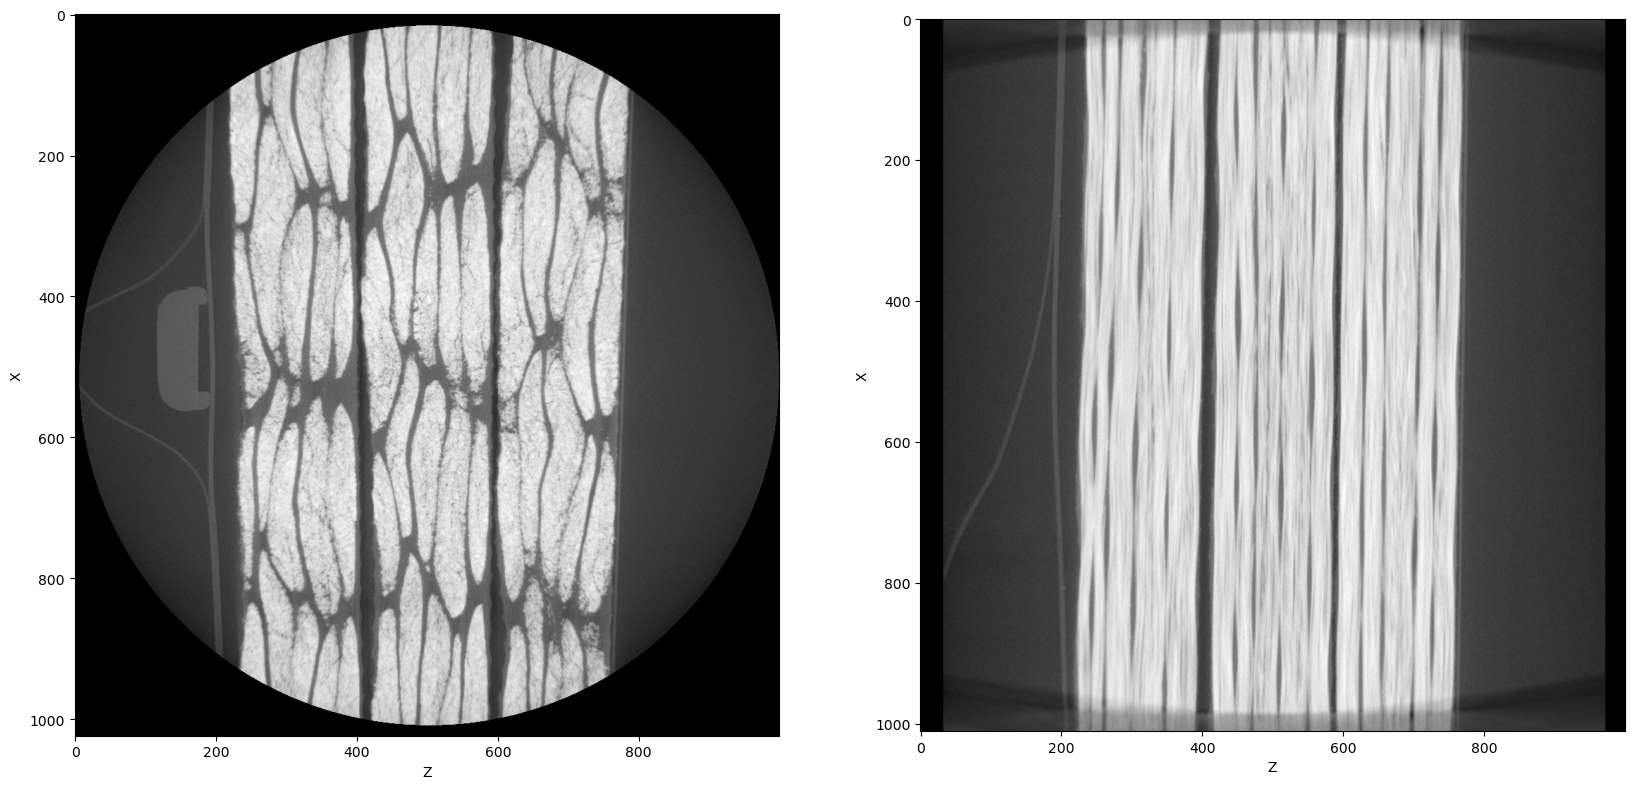

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(20, 20))
i = data_shape[0] // 3
img, _ = reader.read_txrm(file_path, slice_range=((i, i + 1), None, None))
axs[0].imshow(img.squeeze(), cmap='gray')
[(ax.set_xlabel('Z'), ax.set_ylabel('Y')) for ax in axs]
i = data_shape[0] // 3 * 2
img, _ = reader.read_txrm(file_path, slice_range=(None, (i, i + 1), None))
axs[1].imshow(img.squeeze(), cmap='gray')
[(ax.set_xlabel('Z'), ax.set_ylabel('X')) for ax in axs]
plt.show()


In [9]:
data_shape

(1011, 1024, 1000)

# Let's have a need look at the data, to ensure it was loaded correctly.

### Show data
After loading the data, it's always a good idea to have a look at it. 

First we'll create a helper function for adding a simple scale bar to our figures.


In [10]:
def add_scalebar(ax, length=1, scale=1, unit='mm', text=None, ticks=False):
    """Add a scale bar to the plot."""
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    text = f'{length} {unit}' if text is None else text
    
    fontprops = fm.FontProperties(size=18)
    scalebar = AnchoredSizeBar(ax.transData,
                               length / scale, text, 'lower left', 
                               pad=0.3,
                               color='white',
                               frameon=False,
                               size_vertical=3,
                               fontproperties=fontprops)
    ax.add_artist(scalebar)

Let's have a look at the center slice of all three axes.

## YZ-Slice

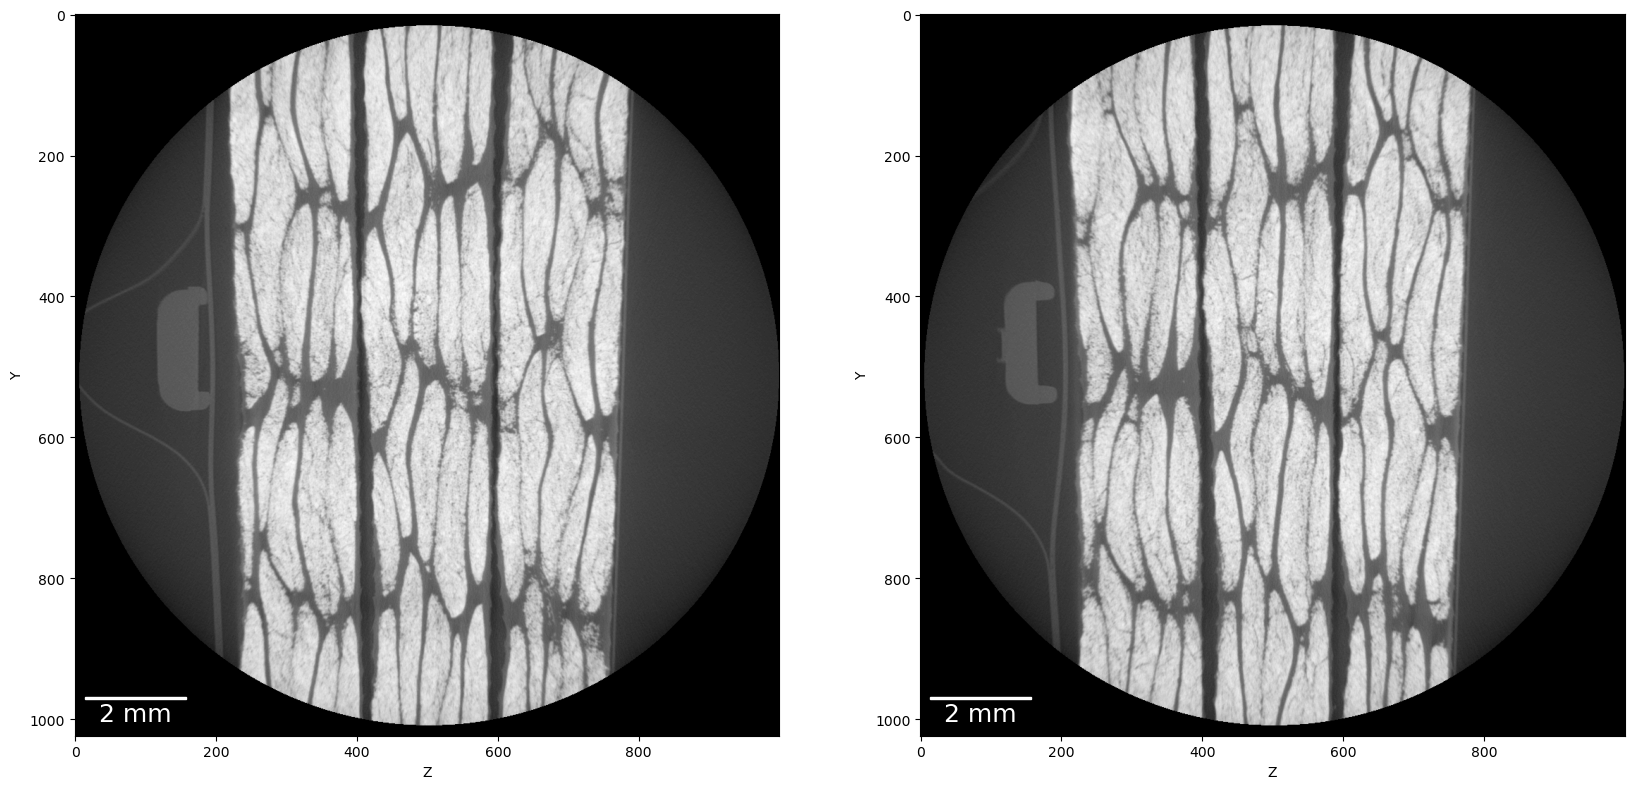

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20, 20))
i = data_shape[0] // 3
img, _ = reader.read_txrm(file_path, slice_range=((i, i + 1), None, None))
axs[0].imshow(img.squeeze(), cmap='gray')
add_scalebar(axs[0], length=2, scale=voxel_size / 1000, ticks=True)
i = data_shape[0] // 3 * 2
img, _ = reader.read_txrm(file_path, slice_range=((i, i + 1), None, None))
axs[1].imshow(img.squeeze(), cmap='gray')
[(ax.set_xlabel('Z'), ax.set_ylabel('Y')) for ax in axs]
add_scalebar(axs[1], length=2, scale=voxel_size / 1000, ticks=True)
plt.show()


## ZX-Slice

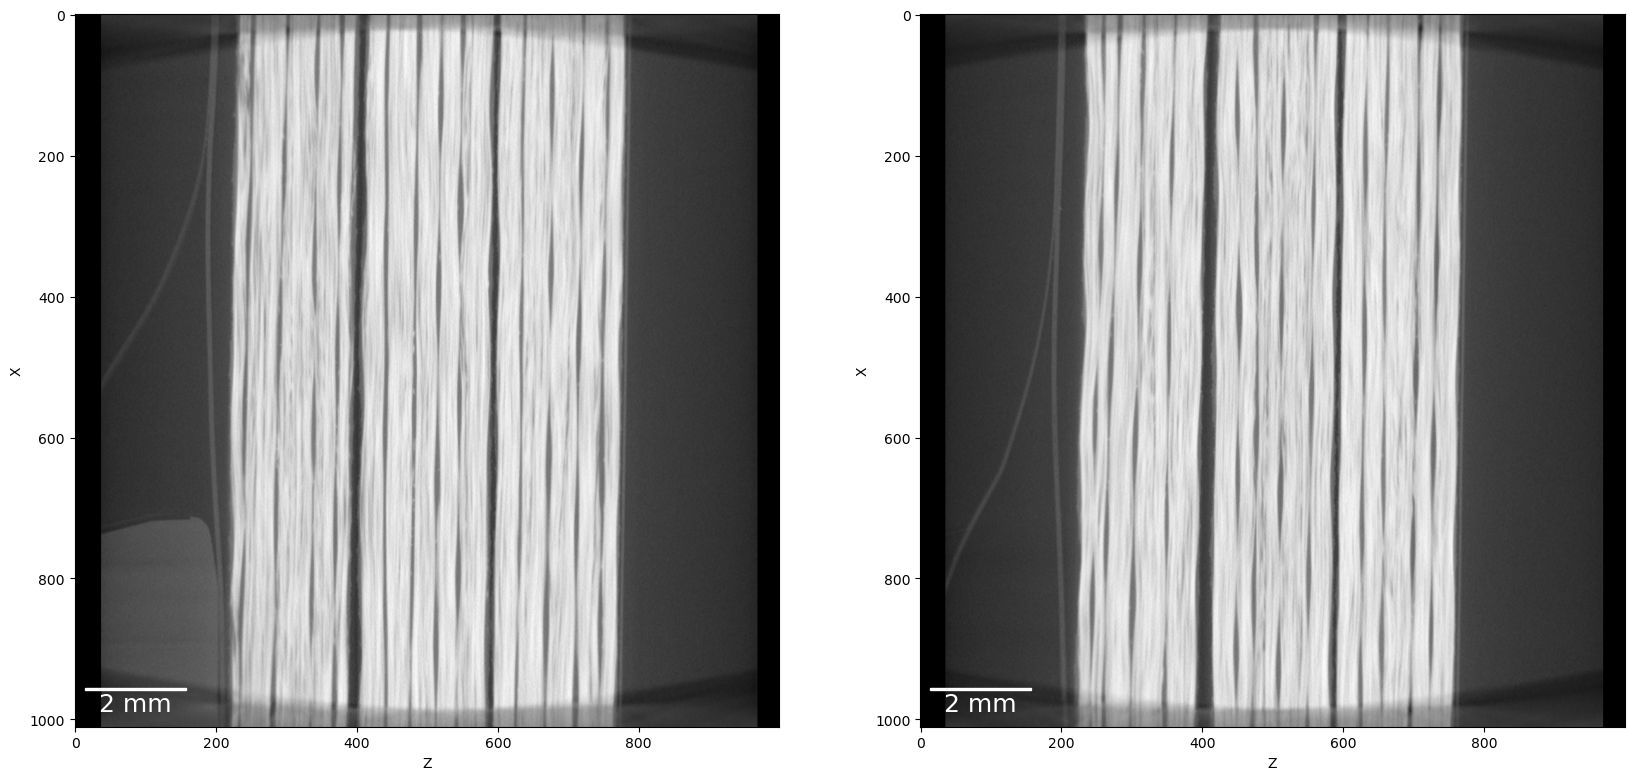

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(20, 20))
i = data_shape[1] // 3
img, _ = reader.read_txrm(file_path, slice_range=(None, (i, i + 1), None))
axs[0].imshow(img.squeeze(), cmap='gray')
add_scalebar(axs[0], length=2, scale=voxel_size / 1000, ticks=True)
i = data_shape[1] // 3 * 2
img, _ = reader.read_txrm(file_path, slice_range=(None, (i, i + 1), None))
axs[1].imshow(img.squeeze(), cmap='gray')
[(ax.set_xlabel('Z'), ax.set_ylabel('X')) for ax in axs]
add_scalebar(axs[1], length=2, scale=voxel_size / 1000, ticks=True)
plt.show()


## YX-Slice

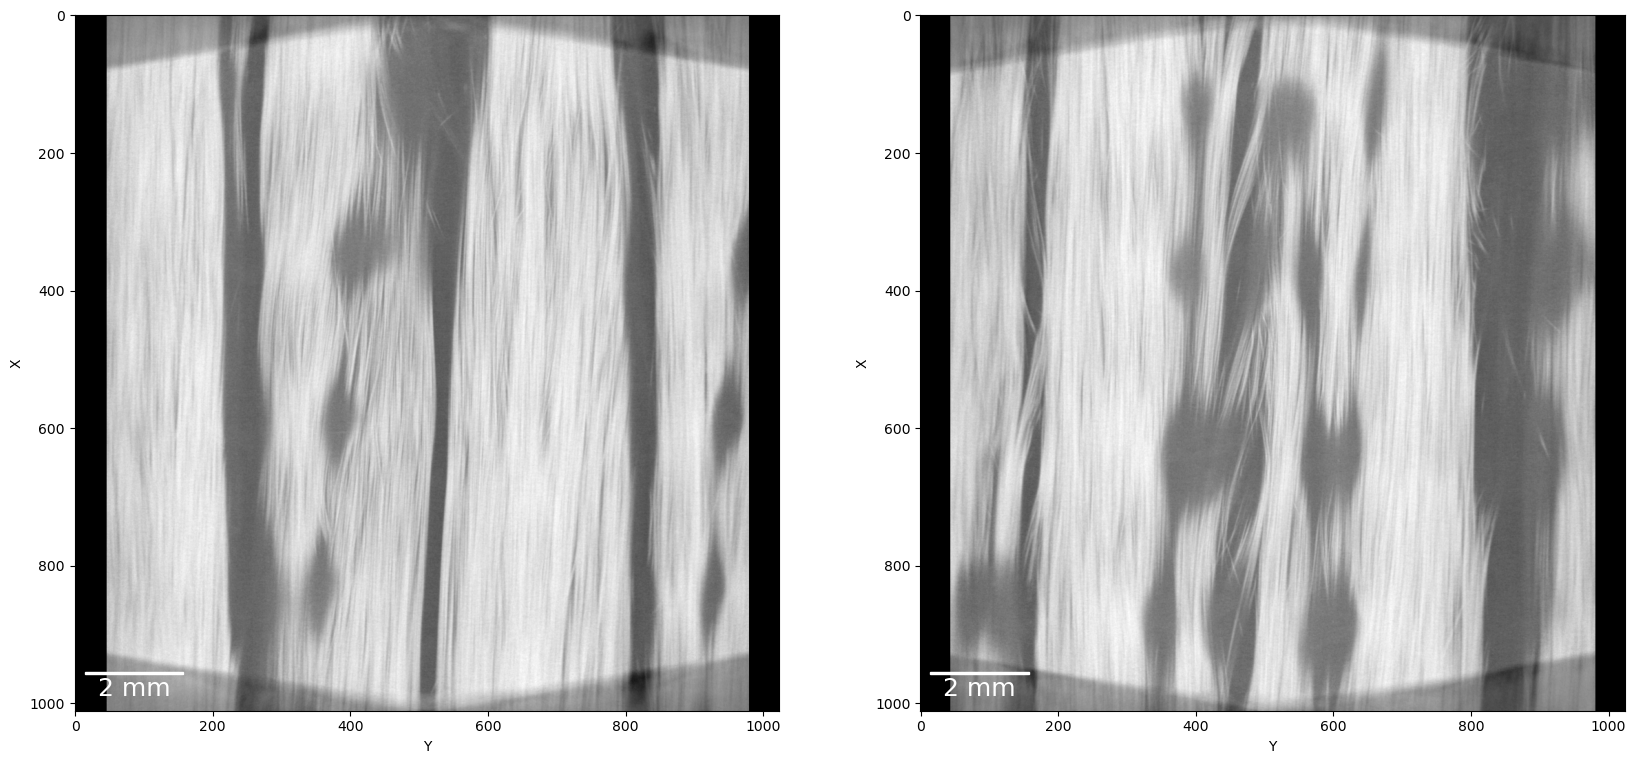

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(20, 20))
i = data_shape[2] // 3
img, _ = reader.read_txm(file_path, slice_range=(None, None, (i, i + 1)))
axs[0].imshow(img.squeeze(), cmap='gray')
add_scalebar(axs[0], length=2, scale=voxel_size / 1000, ticks=True)
i = data_shape[2] // 3 * 2
img, _ = reader.read_txm(file_path, slice_range=(None, None, (i, i + 1)))
axs[1].imshow(img.squeeze(), cmap='gray')
[(ax.set_xlabel('Y'), ax.set_ylabel('X')) for ax in axs]
add_scalebar(axs[1], length=2, scale=voxel_size / 1000, ticks=True)
plt.show()

## Crop data
Some of the data may not of interest to us, so let's crop out the area of interest. You can cut out any part of the data you want to analyze.

The following slice interval is for large domain

# Middle section scan

z_slice = slice(226+192+10, data_shape[2] - 238-172-8) 
y_slice = slice(60, data_shape[1] - 44)
x_slice = slice(100, data_shape[0]-311)  #### NCF

In [14]:
z_slice = slice(226+192+10, data_shape[2] - 238-172-8) 
y_slice = slice(60, data_shape[1] - 44)
x_slice = slice(100, data_shape[0]-311)  #### NCF

# First Section

z_slice = slice(226+192+10, data_shape[2] - 238-172-8)
y_slice = slice(60, data_shape[1] - 44)
x_slice = slice(100, data_shape[0]-311)  #### NCF

In [15]:
# z_slice = slice(230, 390)
# y_slice = slice(100, 900)
# x_slice = slice(100, data_shape[0]-311)  #### NCF

In [16]:
print(f'Original data shape {data_shape}')

Original data shape (1011, 1024, 1000)


In [17]:
print(f'x_slice {x_slice}, y_slice {y_slice}, and z_slice {z_slice}')

x_slice slice(100, 700, None), y_slice slice(60, 980, None), and z_slice slice(428, 582, None)


Let's have a look at the cropped area. The TXM reader can be a bit slow, so we will only look at YZ-slices for now. We may have to come back and adjust the cropping on the X-axis later.

333


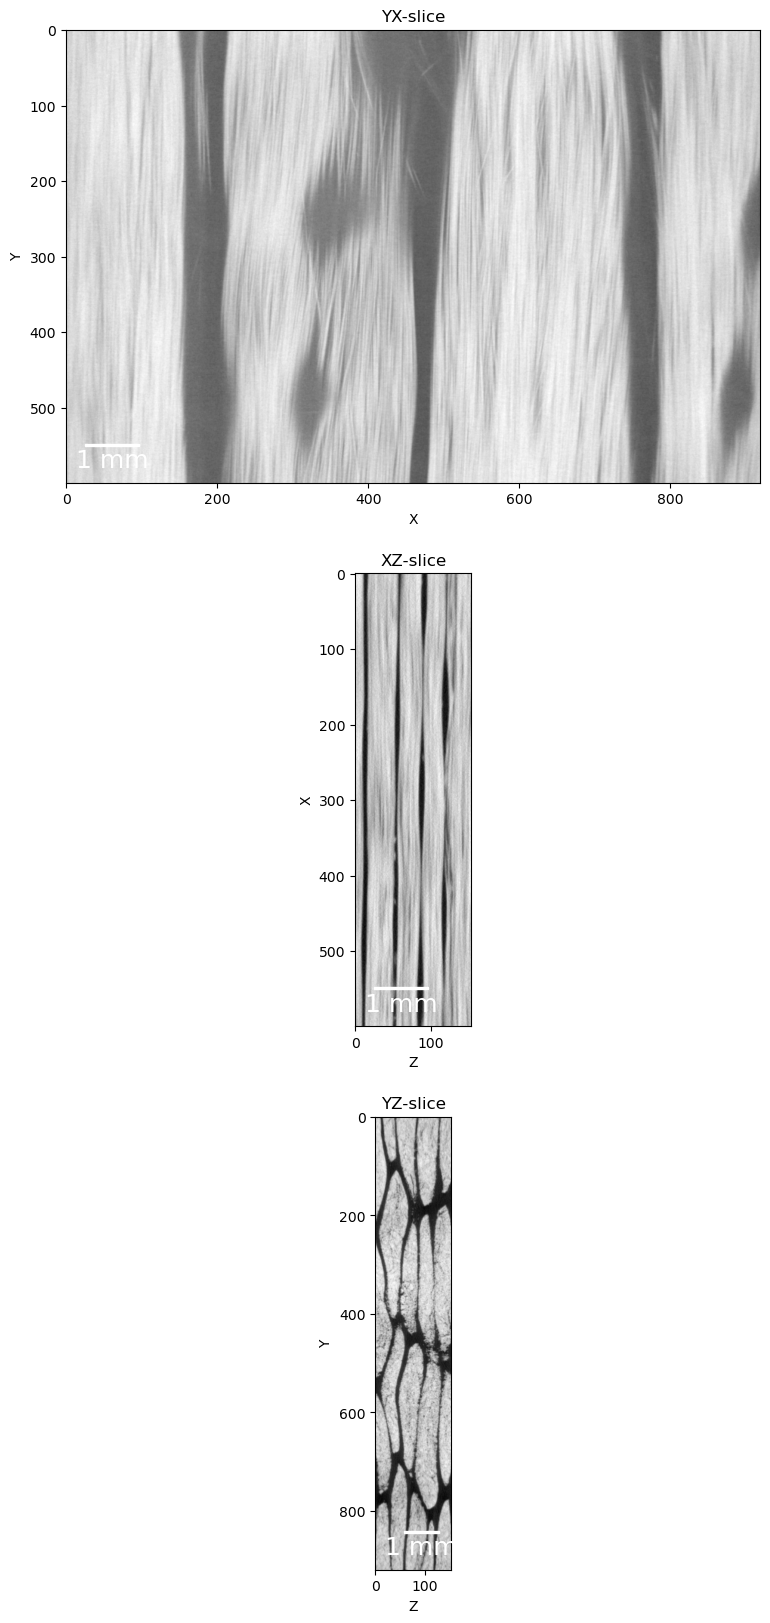

In [18]:
fig, axs = plt.subplots(3, 1, figsize=(20, 20))
i =  data_shape[2] // 3
print(i)
img, _ = reader.read_txrm(file_path, slice_range=((x_slice.start, x_slice.stop), (y_slice.start, y_slice.stop), (i, i + 1)))
axs[0].imshow(img.squeeze(), cmap='gray')
axs[0].set_title('YX-slice')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
add_scalebar(axs[0], length=1, scale=voxel_size / 1000, ticks=True)

i = data_shape[1] // 3
img, _ = reader.read_txrm(file_path, slice_range=((x_slice.start, x_slice.stop), (i, i + 1), (z_slice.start, z_slice.stop)))
axs[1].imshow(img.squeeze(), cmap='gray')
axs[1].set_title('XZ-slice')
axs[1].set_xlabel('Z')
axs[1].set_ylabel('X')
add_scalebar(axs[1], length=1, scale=voxel_size / 1000, ticks=True)

i = data_shape[0] // 3
img, _ = reader.read_txrm(file_path, slice_range=((i, i + 1), (y_slice.start, y_slice.stop), (z_slice.start, z_slice.stop)))
axs[2].imshow(img.squeeze(), cmap='gray')
axs[2].set_title('YZ-slice')
axs[2].set_xlabel('Z')
axs[2].set_ylabel('Y')
add_scalebar(axs[2], length=1, scale=voxel_size / 1000, ticks=True)
plt.show()

In [19]:
# data_shape = (x_slice.stop - x_slice.start, y_slice.stop - y_slice.start, z_slice.stop - z_slice.start)
# print('New proposed shape:', data_shape)

# Create the downsample step
downsample_step = 1 : Correponds to no skip voxel on either side of the domain ~\\
downsample_step = 2 : Correponds to skip 2x2x2 voxel on either side of the domain ~\\
downsample_step = 4 : Correponds to skip 4x4x4 voxel on either side of the domain


In [20]:
downsample_step = 4

In [21]:
data_down, _ = reader.read_txrm(file_path, slice_range=((x_slice.start, x_slice.stop, downsample_step), (y_slice.start, y_slice.stop, downsample_step), (z_slice.start, z_slice.stop, downsample_step)))

In [22]:
data_down.shape

(150, 230, 39)

In [23]:
x_slice = slice(0, data_down.shape[0])
y_slice = slice(0, data_down.shape[1])
z_slice = slice(0, data_down.shape[2])

19


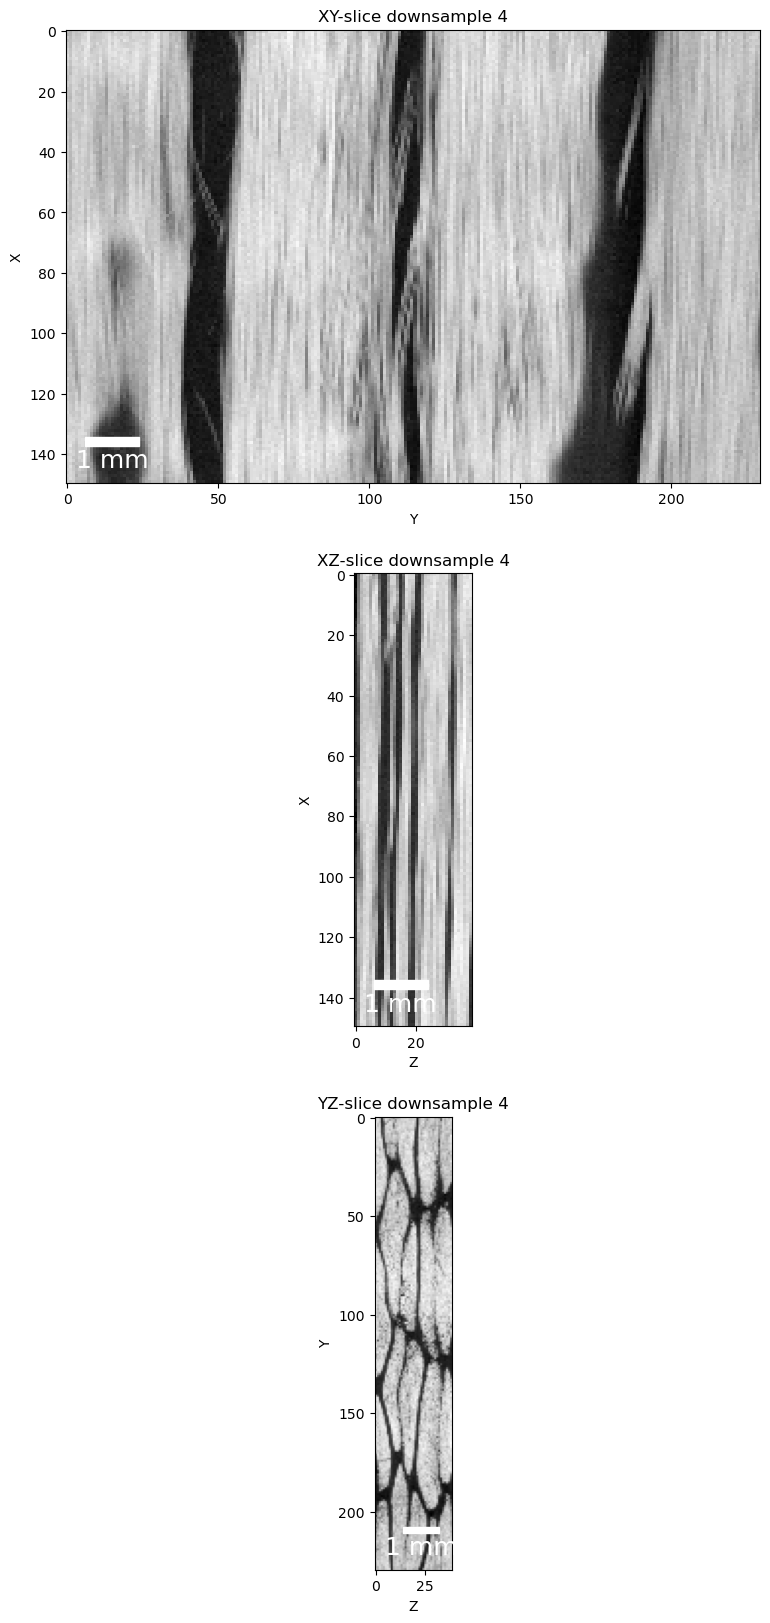

In [24]:
fig, axs = plt.subplots(3, 1, figsize=(20, 20))
i =  data_down.shape[2] // 2
print(i)
img = data_down[x_slice, y_slice, i]
axs[0].imshow(img.squeeze(), cmap='gray')
axs[0].set_title(f'XY-slice downsample {downsample_step}')
axs[0].set_xlabel('Y')
axs[0].set_ylabel('X')
add_scalebar(axs[0], length=1, scale=voxel_size*downsample_step / 1000, ticks=True)

i = data_down.shape[1] // 2
img = data_down[x_slice, i+62, z_slice]
axs[1].imshow(img.squeeze(), cmap='gray')
axs[1].set_title(f'XZ-slice downsample {downsample_step}')
axs[1].set_xlabel('Z')
axs[1].set_ylabel('X')
add_scalebar(axs[1], length=1, scale=voxel_size*downsample_step / 1000, ticks=True)

i = data_down.shape[0] // 2
img = data_down[i, y_slice, z_slice]
axs[2].imshow(img.squeeze(), cmap='gray')
axs[2].set_title(f'YZ-slice downsample {downsample_step}')
axs[2].set_xlabel('Z')
axs[2].set_ylabel('Y')
add_scalebar(axs[2], length=1, scale=voxel_size*downsample_step / 1000, ticks=True)
plt.show()

## Save as RAW
To work with the data, we will save it as a raw data file, which will allow us to access the data using ```numpy.memmap```. Using a memory-mapped file is both convenient and fast, especially since we will be accessing the data many times from different processes.

We will be placing all our processed data in a temporary folder, as it can be re-created using this notebook if deleted. We will also use data in the temp folder as a cache, so we don't have to create the RAW volume if it already exists. Thus, if you change the volume cropping etc., be sure to delete the RAW volume from the temp folder and create a new one.

In [25]:
temp_folder = './tmp/'
if str(os.path.exists(temp_folder)) == "True":
    print(".tmp temporary file exists")
    shutil.rmtree(temp_folder, ignore_errors=True)

if temp_folder and not os.path.exists(temp_folder):
    os.mkdir(temp_folder)

.tmp temporary file exists


In [26]:
data_shape = data_down.shape
print('New shape:', data_shape)

New shape: (150, 230, 39)


In [27]:
data_path = os.path.join(temp_folder, file_name + f'_{x_slice.start}-{x_slice.stop}_{y_slice.start}-{y_slice.stop}_{z_slice.start}-{z_slice.stop}.raw')
if not os.path.exists(data_path):
    
    # Number of images read at a time.
    # Reduce this to lower memory usage.
    chunck_size = 20
    
    print('Creating new file:', data_path)
    data = np.memmap(data_path, dtype=np.uint16, shape=data_down.shape, mode='w+')
    
    for i in tqdm(range(0, data.shape[2], chunck_size)):
        z0 = i + z_slice.start
        z1 = min(z_slice.stop, z0 + chunck_size)
        
        chunck = data_down[x_slice, y_slice, z0:z1]
        data[:, :, i:i + chunck_size] = chunck #np.rot90(chunck, k=3, axes=(0, 2))
        

else:
    print('Using existing file:', data_path)
data = np.memmap(data_path, dtype=np.uint16, shape=data_down.shape, mode='r')

Creating new file: ./tmp/JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm_0-150_0-230_0-39.raw


100%|██████████| 2/2 [00:00<00:00, 779.39it/s]


Let's have a look some slices from all three axes.

**Important: Remember to look at figures below to verify that the correct data is loaded into the ```data``` variable. If you've changed the slicing or the data you're working with, you may want to delete the RAW data cached in the ```temp_folder``` folder.**

(230, 39)
(150, 39)
(150, 230)


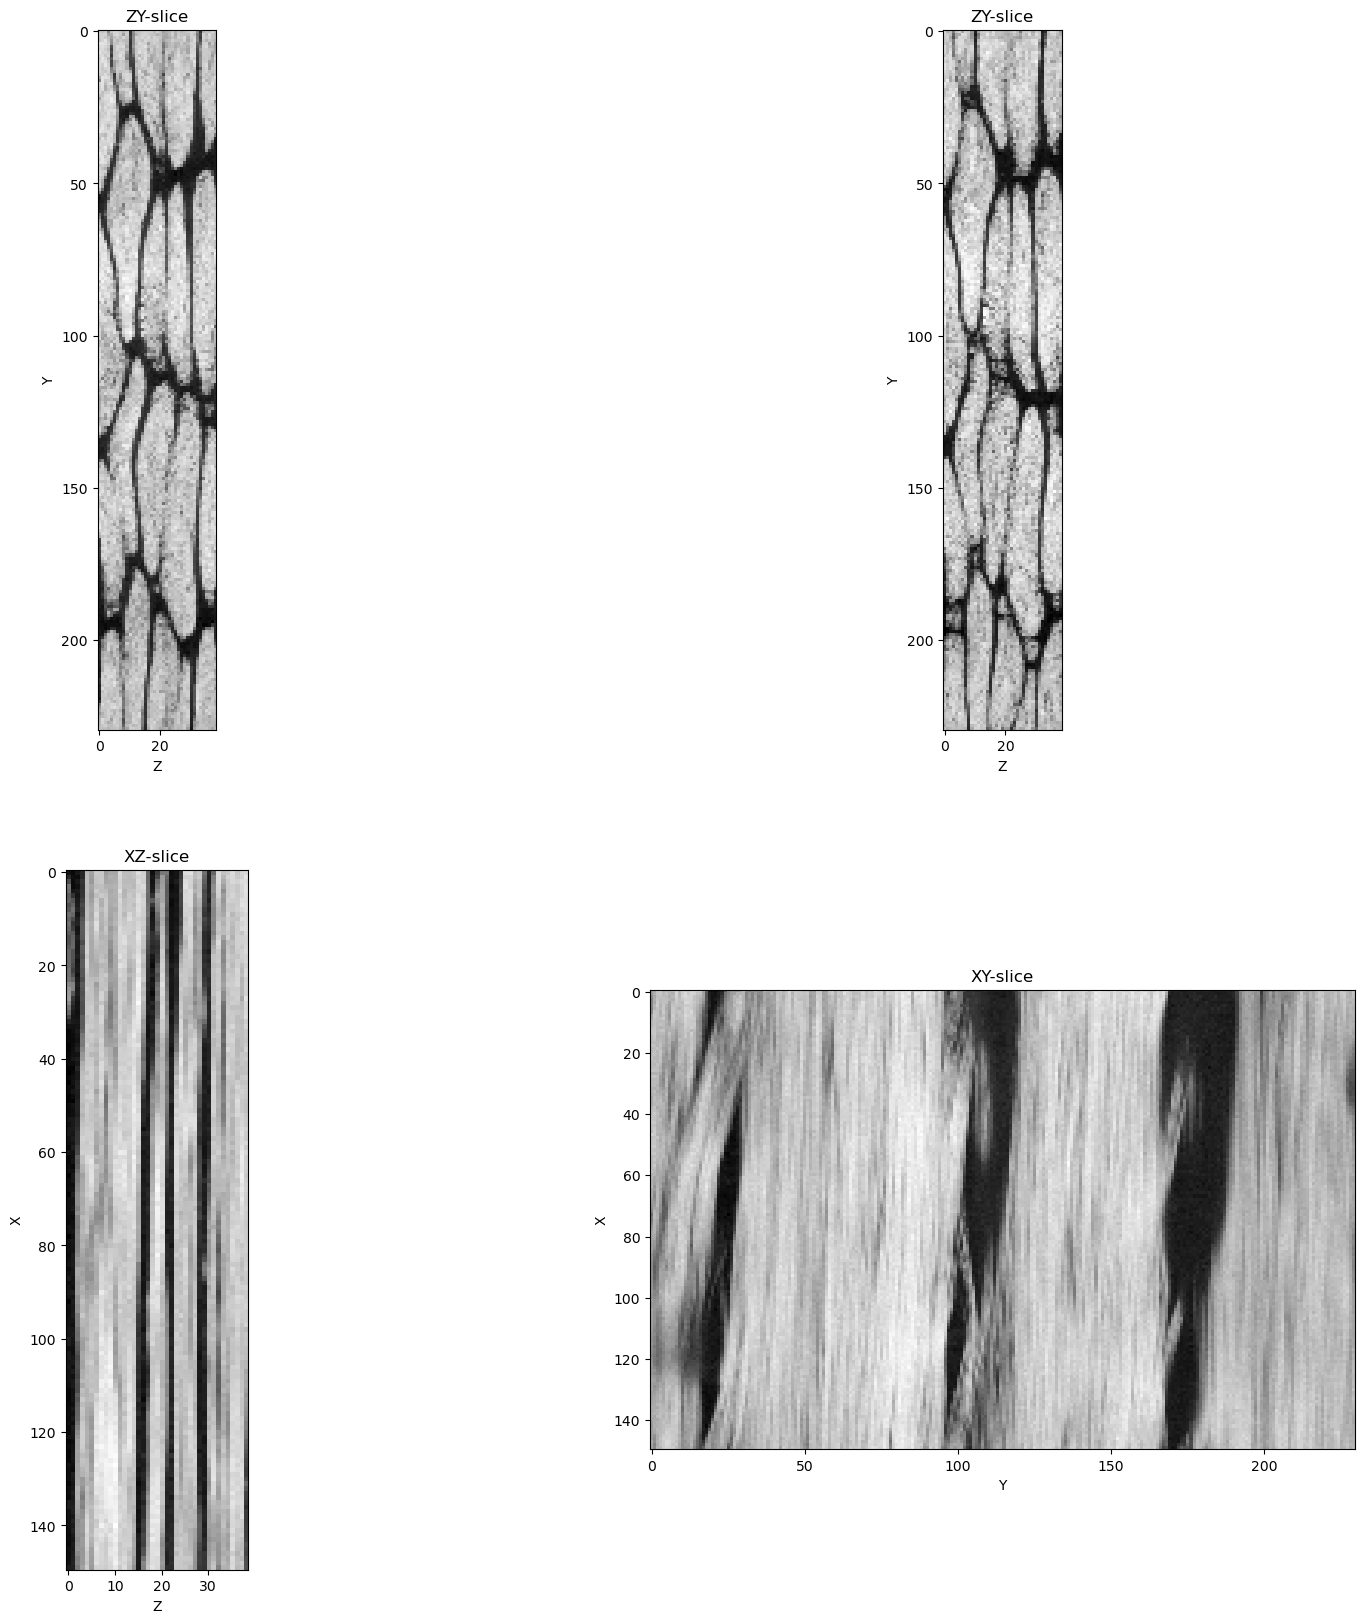

In [28]:
plt.figure(figsize=(20, 20))
ax = plt.subplot(2, 2, 1)
ax.imshow(data[data.shape[0] // 3], cmap='gray')
print(data[data.shape[0] // 3].shape)
ax.set_title('ZY-slice')
ax.set_xlabel('Z')
ax.set_ylabel('Y')
# add_scalebar(ax, length=2, scale=voxel_size*downsample_step / 1000, ticks=True)

ax = plt.subplot(2, 2, 2)
ax.imshow(data[data.shape[0] // 3 * 2], cmap='gray')
ax.set_title('ZY-slice')
ax.set_xlabel('Z')
ax.set_ylabel('Y')
# add_scalebar(ax, length=2, scale=voxel_size*downsample_step / 1000, ticks=True)

ax = plt.subplot(2, 2, 3)
ax.imshow(data[:, data.shape[1] // 4], cmap='gray')
print(data[:, data.shape[1] // 4].shape)
ax.set_title('XZ-slice')
ax.set_xlabel('Z')
ax.set_ylabel('X')
# add_scalebar(ax, length=2, scale=voxel_size*downsample_step / 1000, ticks=True)

ax = plt.subplot(2, 2, 4)
ax.imshow(data[..., data.shape[-1] // 4], cmap='gray')
print(data[..., data.shape[-1] // 4].shape)
ax.set_title('XY-slice')
ax.set_xlabel('Y')
ax.set_ylabel('X')
# add_scalebar(ax, length=2, scale=voxel_size*downsample_step / 1000, ticks=True)
plt.show()

## Choosing fiber threshold
To choose a good intensity threshold for the fibers we can use a histogram and choose the value manually. Alternatively we can use a method such as Otsu's threshold. For choosing the threshold we make sure only to include inside-sample data. This makes it easier to separate foreground (fibers) and background inside the sample.

In [29]:
threshold_bins = 512
threshold_data = data #[:, 50:-50, 50:-50]


In [30]:
otsu_threshold = filters.threshold_otsu(threshold_data.reshape(-1, 1), nbins=threshold_bins)
hand_picked_threshold = 34500 #41000 
print('Otsu threshold:', otsu_threshold)
print('Hand-picked threshold:', hand_picked_threshold)

Otsu threshold: 36784
Hand-picked threshold: 34500


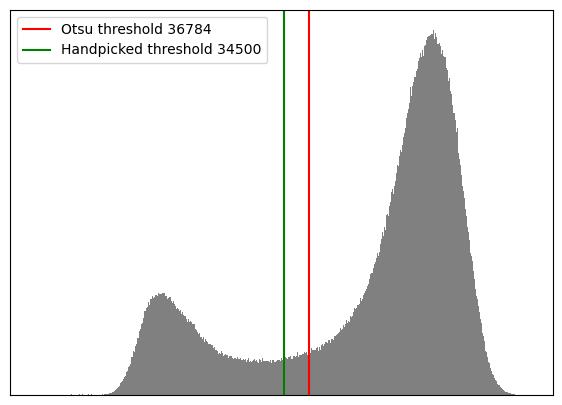

In [31]:
plt.figure(figsize=(7, 5))
ax = plt.subplot(1, 1, 1)
ax.hist(threshold_data.ravel(), bins=threshold_bins, density=True, color='gray')
ax.axvline(otsu_threshold, c='r', label=f'Otsu threshold {otsu_threshold}')
ax.axvline(hand_picked_threshold, c='g', label=f'Handpicked threshold {hand_picked_threshold}')
ax.legend(loc='upper left', fontsize='medium')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
ax.set_xlabel('Volume intensity distribution')
plt.show()

In [32]:
data_shape

(150, 230, 39)

## Structure tensor
We set $\sigma$ and $\rho$ based on the size of the fibers that we want to analyze. For more details see the related paper and *StructureTensorFiberAnalysisDemo* notebook. 

Then, we set the block size (```crop_size```), which will determine the maximum size of the blocks we will partition the data into for the ST calculation. The maximum black size will depend on ```crop_size```, the ```truncate``` value used for Gaussian filters (default is 4), and $\rho$ or $\sigma$ (usually $\rho$ because ti is largest).

We also set the ```fiber_threshold``` and specify a list of devices to use for the calculation. The list determines how the blocks will be distributed between devices for calculations. If we have a dual GPU system supporting CUDA, we can specify ```['cuda:0', 'cuda:1']```, which will distribute blocks evenly between the two GPUs. ```['cuda:0', 'cuda:1', 'cuda:1']``` would move two thirds to GPU 1, while ```['cuda:0', 'cuda:1', 'cpu']``` will move one third of the blocks to the CPU. **Remember to update the ```device``` list to match your system resources. Specifying CUDA devices that are not available will result in exceptions and/or undefined behaviour.** If you don't have CUDA GPUs available, just set ```device = ['cpu']``` and specify the number of processes later.

The ```class_vectors``` area used to segment the voxels based on the orientations of the ST eigenvectors. It is a list of unit vectors, which represent each of the fiber classes. The first vector is considered the primary orientation and will be used for calculating orientation metrics for each voxel. For more details see the related paper and *StructureTensorFiberAnalysisDemo* notebook.

Lastly, ```bins_per_degree``` determines the number of bins used per degree when aggregating the orientation metrics. 

# Here, select the fiber_thresold to be hand picked or otsu 

In [33]:
r = fiber_diameter / 2 / voxel_size
sigma = round(np.sqrt(r**2 / 2), 2)
rho = 4 * sigma

print('sigma:', sigma)
print('rho:', rho)

crop_size = 230
print('crop_size:', crop_size)
print('Maximum block size:', crop_size + int(4 * max(rho, sigma) + 0.5))

# fiber_threshold = hand_picked_threshold
fiber_threshold = otsu_threshold
# Important: Listing invalid CUDA devices may results in exceptions.
device = ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']

class_names = ['0', '45', '-45', '90']
class_vectors = np.array([[0, 0, 1], [0, 1, 1], [0, -1, 1], [0, 1, 0]], dtype=np.float64)
class_vectors /= np.linalg.norm(class_vectors, axis=-1)[..., np.newaxis]

bins_per_degree = 4

sigma: 0.43
rho: 1.72
crop_size: 230
Maximum block size: 237


We can use the ```get_crops``` function to partition the data into blocks (```crops```) with proper padding. However, we will actually only use ```len(crops)``` here, as we will use ```multiprocessing``` to distribute the blocks accross multiple devices. We may include a function just for calculating the number of blocks/crops at a later point.

In [34]:
fiber_threshold

36784

In [35]:
# Get crops as memory views.
crops, crop_positions, crop_paddings = get_crops(data, max(sigma, rho), crop_size=crop_size)

We will be using the ```structure_tensor_analysis_v1``` function to calculate the structure tensor, $S$, and do the eigendecomposition for the blocks in parallel. We will be saving the following metrics to the disk using memory maps created below:

1. ```vec_class``` contains a label for each voxel. 
2. ```eta_os``` contains a stiffness estimate, $\eta_O$, for each voxel
3. ```theta``` contains the angle, $\theta$ between ```vec``` and class 0, at each voxel.
4. ```out_xy_angle``` angle between```vec``` and the XY-plane (out-of-plane orientation).
5. ```in_xy_angle``` rotation of ```vec``` in the XY-plane (in-plane orientation).

To calcualte these metrics, the ```structure_tensor_analysis_v1``` uses the ```calculate_angles``` function, which is explained further in the *StructureTensorFiberAnalysisDemo* notebook. However, the metrics returned by ```structure_tensor_analysis_v1``` have been aggregated (binned), as returning all the metrics for each block unaggregated would obvously consume large amounts of memory and be infeasible for large volumes. We will combine the aggregated data from each block afterwards.

In the code below we create memory-mapped files for the eigenvectors, along with three other metrics. The ```structure_tensor_analysis_v1``` function will be using these to save the metrics for the volume straight to the disk, which may require a significant amount of disk space, but shouldn't result in memory issues. Besides the five types shown below, the function also supports saving $S$ and the eigenvalues. See ```structure_tensor_workers.py``` for details. In the example below we will be saving the results using 16-bit precision data types to save space. This is usually fine for visualization and most statistics. Saving the metrics to disk is optional. **If you don't need the per voxel orientations for later, don't create the memory-maps and remove the entries from the ```init_args``` dictionary below.** This will save you a lot of disk space and probably reduce the processing time.

In [36]:
# Output names, dtypes and shapes.
map_names = ['vec', 'vec_class', 'theta', 'in_xy_angle', 'out_xy_angle']
map_dtypes = [np.float16, np.uint8, np.float16, np.float16, np.float16]
map_shapes = [(3, ) + data.shape, data.shape, data.shape, data.shape, data.shape]

# Output paths.
map_paths = {n: data_path.replace('.raw', f'-{n}-{sigma}-{rho}-{fiber_threshold}.raw') for n in map_names}
map_paths['vec'] = data_path.replace('.raw', f'-vec-{sigma}-{rho}.raw')

# Create maps.
maps = {}
new_maps = {}

for n, dtype, shape in zip(map_names, map_dtypes, map_shapes):
    path = map_paths[n]
    create_map = not os.path.exists(path) or os.stat(path).st_size != np.product(shape) * np.dtype(dtype).itemsize
    
    if create_map:
        print(f'Creating memory mapped file:\n{path}')
        mmap = np.memmap(path, dtype=dtype, shape=shape, mode='w+')
        if np.issubdtype(dtype, np.floating) and n not in ['S', 'val', 'vec']:
            mmap[:] = np.nan
            
        new_maps[n] = (path, dtype)
        
    maps[n] = np.memmap(path, dtype=dtype, shape=shape, mode='r')

Creating memory mapped file:
./tmp/JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm_0-150_0-230_0-39-vec-0.43-1.72.raw
Creating memory mapped file:
./tmp/JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm_0-150_0-230_0-39-vec_class-0.43-1.72-36784.raw
Creating memory mapped file:
./tmp/JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm_0-150_0-230_0-39-theta-0.43-1.72-36784.raw
Creating memory mapped file:
./tmp/JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm_0-150_0-230_0-39-in_xy_angle-0.43-1.72-36784.raw
Creating memory mapped file:
./tmp/JCB-11-14-19_LFOV-B2-10s-LE3-60kV-10w_recon.txm_0-150_0-230_0-39-out_xy_angle-0.43-1.72-36784.raw


In [37]:
# Get memory maps.
vec = maps['vec']
vec_class = maps['vec_class']
theta = maps['theta']
in_xy_angle = maps['in_xy_angle']
out_xy_angle = maps['out_xy_angle']

Now we're finally ready to perform the analysis. We will be using ```multiprocessing.Pool``` to distribute the work across multiple CPU cores. If specified in the ```device``` list, the CPU will offload the majority of the work to a GPU, otherwise it'll do the calculations itself. Here, we will create four processes for each device in the list (```processes=4 * len(device)```). As our ```device``` list contains four GPUs, we will be starting 16 processes, four for each GPU. Beware that this may require a significant amount of GPU memory. **If you experience out of memory exceptions, either reduce ```crop_size``` and/or the number of processes per device.** Change the number of processes to fit your system. 

In [38]:
if __name__ ==  '__main__':
    results = []
    
    init_args = {'data': data_path,
                 'dtype': data.dtype,
                 'shape': data.shape,
                 'rho': rho,
                 'sigma': sigma,
                 'crop_size': crop_size,
                 'threshold': fiber_threshold,
                 'class_vectors': class_vectors,
                 'bins_per_degree': bins_per_degree,
                 'device': device
                }
    
    # Add output maps to args.
    for n in new_maps:
        path, dtype = new_maps[n]
        init_args[n] = path
        init_args[f'{n}_dtype'] = dtype

    with Pool(processes=4 * len(device), initializer=init_worker, initargs=(init_args,)) as pool:
        for res in tqdm(pool.imap_unordered(structure_tensor_analysis_v1, range(len(crops)), chunksize=1), total=len(crops)):
            results.append(res)

100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


All shared variables are passed to the workers using the ```init_args``` dictionary and ```init_worker```function. This function is only called once per worker. When called, it will create all the memory-maps needed to read and write data during calculations, based on ```init_args```. We will use the ```pool.imap_unordered``` function to tell the workers to perform the calculations for a block, by passing the ```structure_tensor_analysis_v1``` function along with the index of the block which we want to analyze. The returned results are a tuple of aggregated metrics, as decribed earlier. For more details see the ```structure_tensor_analysis_v1``` code. Below we will show have to combine the aggregated metrics and display them as histograms.

Another option is to save all the metrics to disk (using memory-maps as described earlier) with reasonable precision and perform the statistics directly on the full orientation volumes. This approach would be similar to what's done in the *StructureTensorFiberAnalysisDemo* notebook, except there data is kept in memory instead of on the disk. If you use this approach you may simply ignore the aggregated data returned by ```structure_tensor_analysis_v1```, but it will require you to use a significant amount of disk space to store all the orientation and segmentation data. If the volumes are very big, working with them may also be slow and memory intensive, even if you use ```memmap``` to access the data.

## Histograms
The figures above are great for validating that we've done the calculations correctly and that our results are meaningful. However, even with this many figures we're only actually showing a very small fraction of the volume. To get a proper overview of the fiber orientations and classes we need to aggregate the information in a meaningful way. One way to do this is to use histograms. Since we have saved all the data to the memory maps, we just need to aggregate the data that they contain.

**Note: To load the memory maps from disk later, simply use ```np.memmap```, for example ```theta = np.memmap(path, dtype=dtype, shape=shape, mode='r')```.**

By combining the threshold mask (indicating what is fiber) with the class labels, we can create a fiber class mask for each class.

In [39]:
# Create threshold mask.
threshold_mask = data >= fiber_threshold
# Count number of fiber voxels.
fiber_count = np.count_nonzero(threshold_mask)
# Create a mask for each fiber class.
vec_class_masks = [threshold_mask] + [(vec_class == l) & threshold_mask for l in range(len(class_vectors))]

This is the fiber volume fraction based on thresholding on total pixel ratio between fiber and matrix. The fiber Vf within a yarn was not considered. For the true global fiber Vf, one need to know the fiber Vf inside a yarn then multipy with the following fractions.

In [40]:
print('Otsu fiber fraction:', round(np.count_nonzero(data>=otsu_threshold) / data.size, 3))
print('Hand-picked fiber fraction:', round(np.count_nonzero(data >= hand_picked_threshold) / data.size, 3))

Otsu fiber fraction: 0.759
Hand-picked fiber fraction: 0.783


### Fiber fractions of individual class of fiber
Using these masks we calculate the fraction of the fibers belonging to each class within the global Vf.

In [41]:
fiber_fractions = [np.count_nonzero(m) / fiber_count for m in vec_class_masks[1:]]
for i, f in enumerate(fiber_fractions):
    c = class_names[i]
    print(f'Fraction ({c}): {round(f, 6)}')

Fraction (0): 0.999478
Fraction (45): 9e-05
Fraction (-45): 0.000419
Fraction (90): 1.3e-05


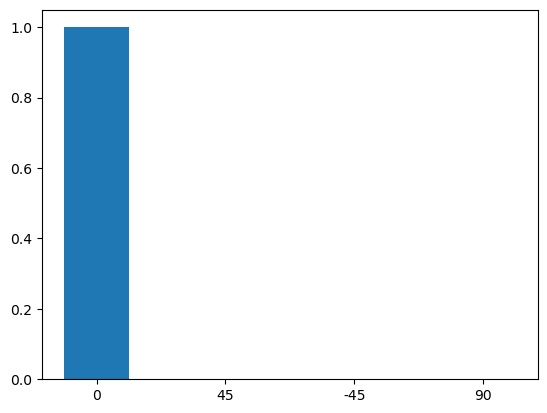

In [42]:
plt.bar(class_names, fiber_fractions, align='center', width=0.5)
plt.xticks(range(len(fiber_fractions)))
plt.show()

This shows that there is only one class of fiber direction $0^o$.

## Slices
As we chose to save the eigenvectors for each voxel in the ```data``` volume to the disk using the ```vec``` memory map, we can actually access all the eigenvectors along with the original data if we like. We also have orientation metrics avilable through the ```theta```, ```in_xy_angle```, ```out_xy_angle``` memory-maps, but they were saved with low precision intended only for visualization in other applications and we will not be using these data in this notebook.

Let's grab som data and their ST eigenvectors. The vectors were saved as ```float16``` to save space, but before we can plot them we have to change their type. Generally, CPUs do not support ```float16``` natively, so using this data type for anything but storing large data sets is generally not advisable.

**Note: We've chosen some specific slices from our data, such as Z-index 40 and 80. If you Z-dimension size is 80 or less this will give an error. You can easily change which slices will be shown in the figures below, by changing/adding/removing the ```data_slices``` and ```vec_slices``` indices.** 

In [43]:
data_slices = [
    data[data.shape[0] // 2].copy(),
    data[:, data.shape[1] // 2].copy(),
    data[:, :, data.shape[2] // 2].copy(),
    data[:, :, data.shape[2] // 2].copy(),
]

vec_slices = [
    vec[:, vec.shape[1] // 2].astype(np.float32),
    vec[:, :, vec.shape[2] // 2].astype(np.float32),
    vec[:, :, :, vec.shape[3] // 2].astype(np.float32),
    vec[:, :, :, vec.shape[3] // 3].astype(np.float32),
]
data_slices_axis = [['Y', 'Z'],
                    ['X', 'Z'],
                    ['X', 'Y'], 
                    ['X', 'Y']
                    ]

Let's can have a look at the data and the first element of the eigenvectors.

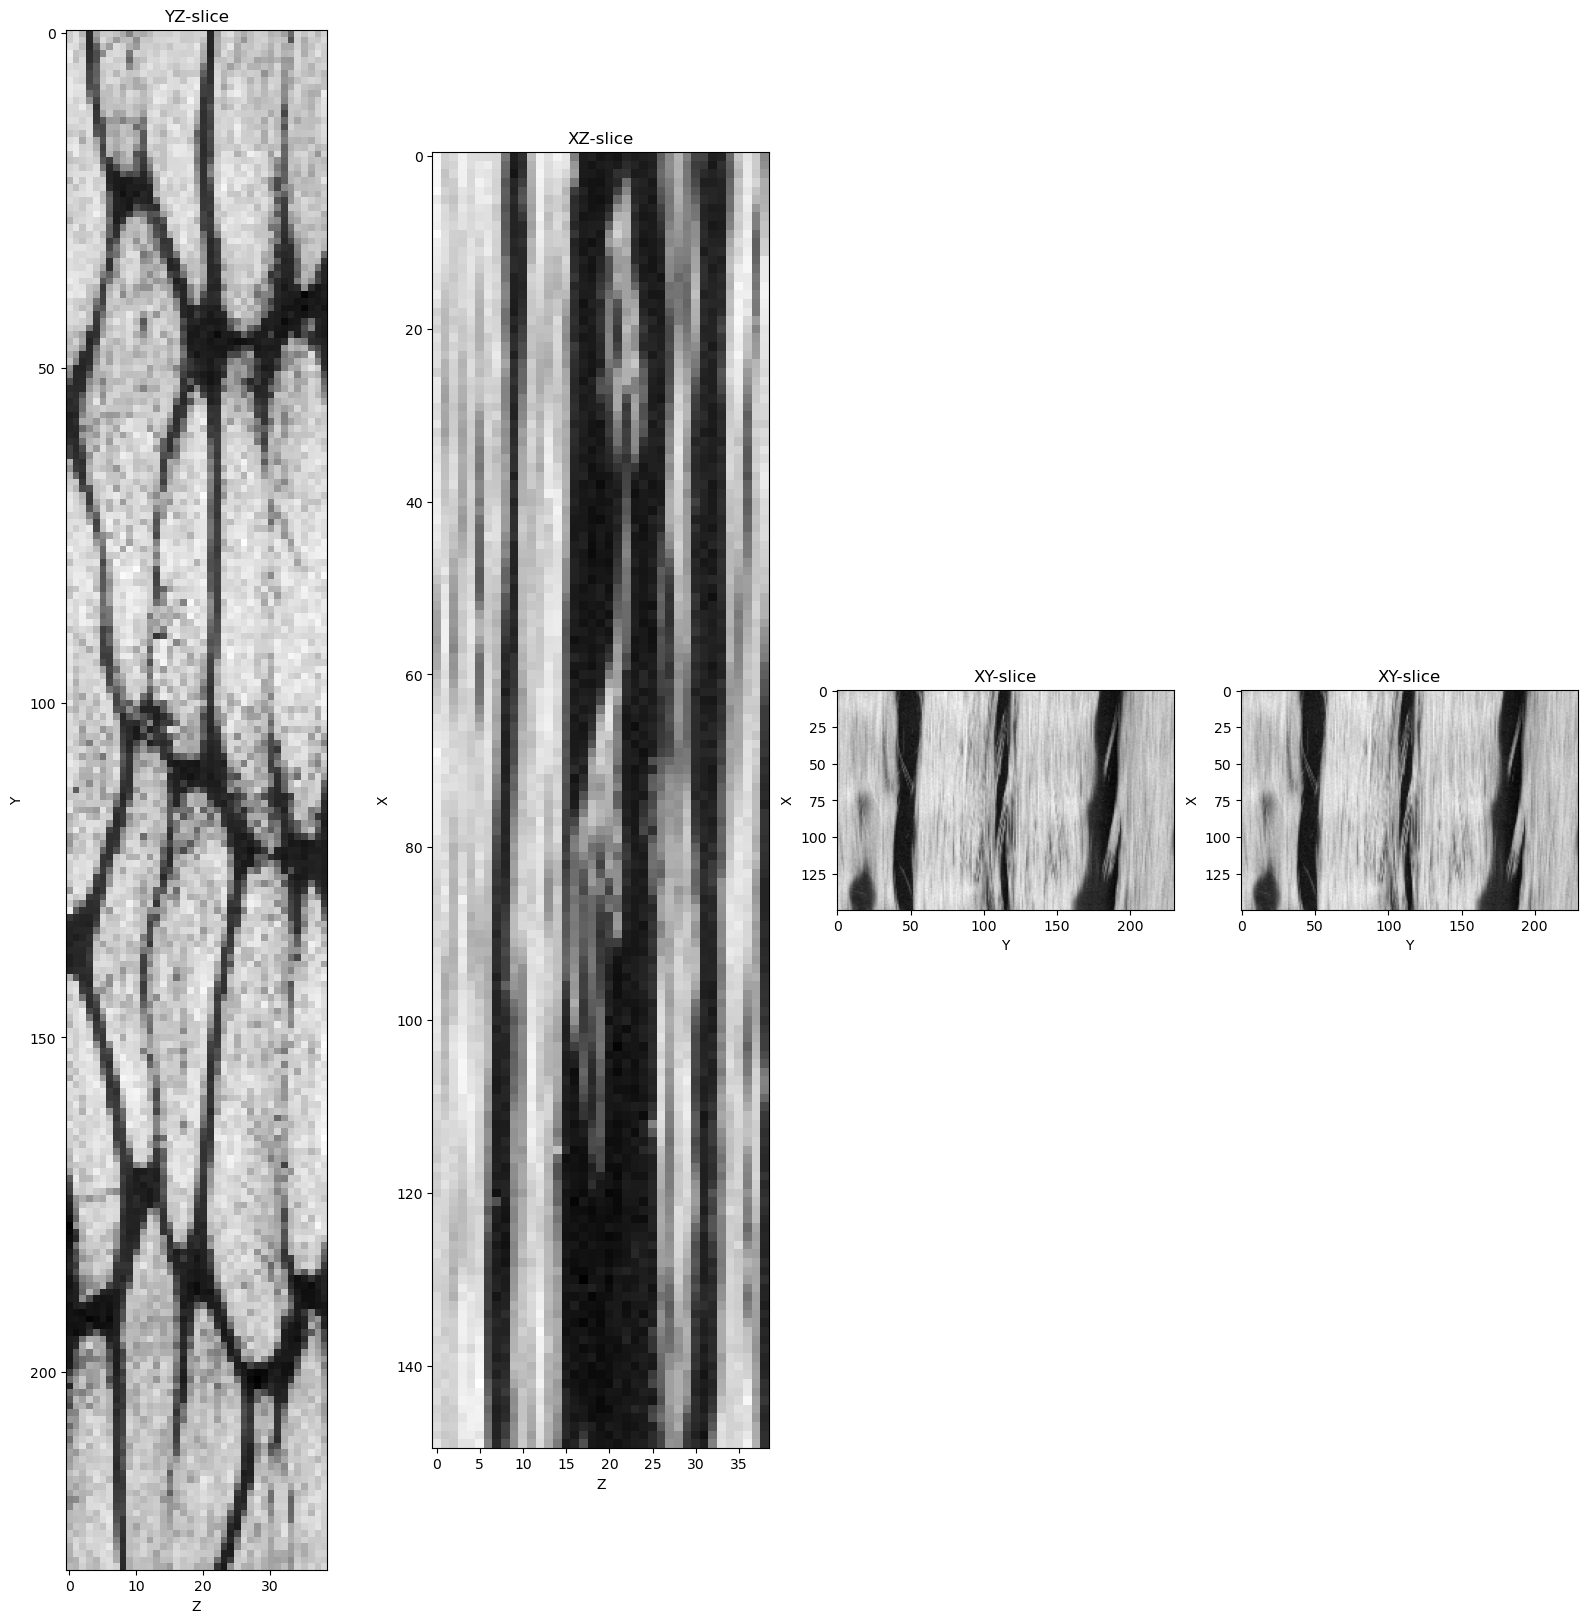

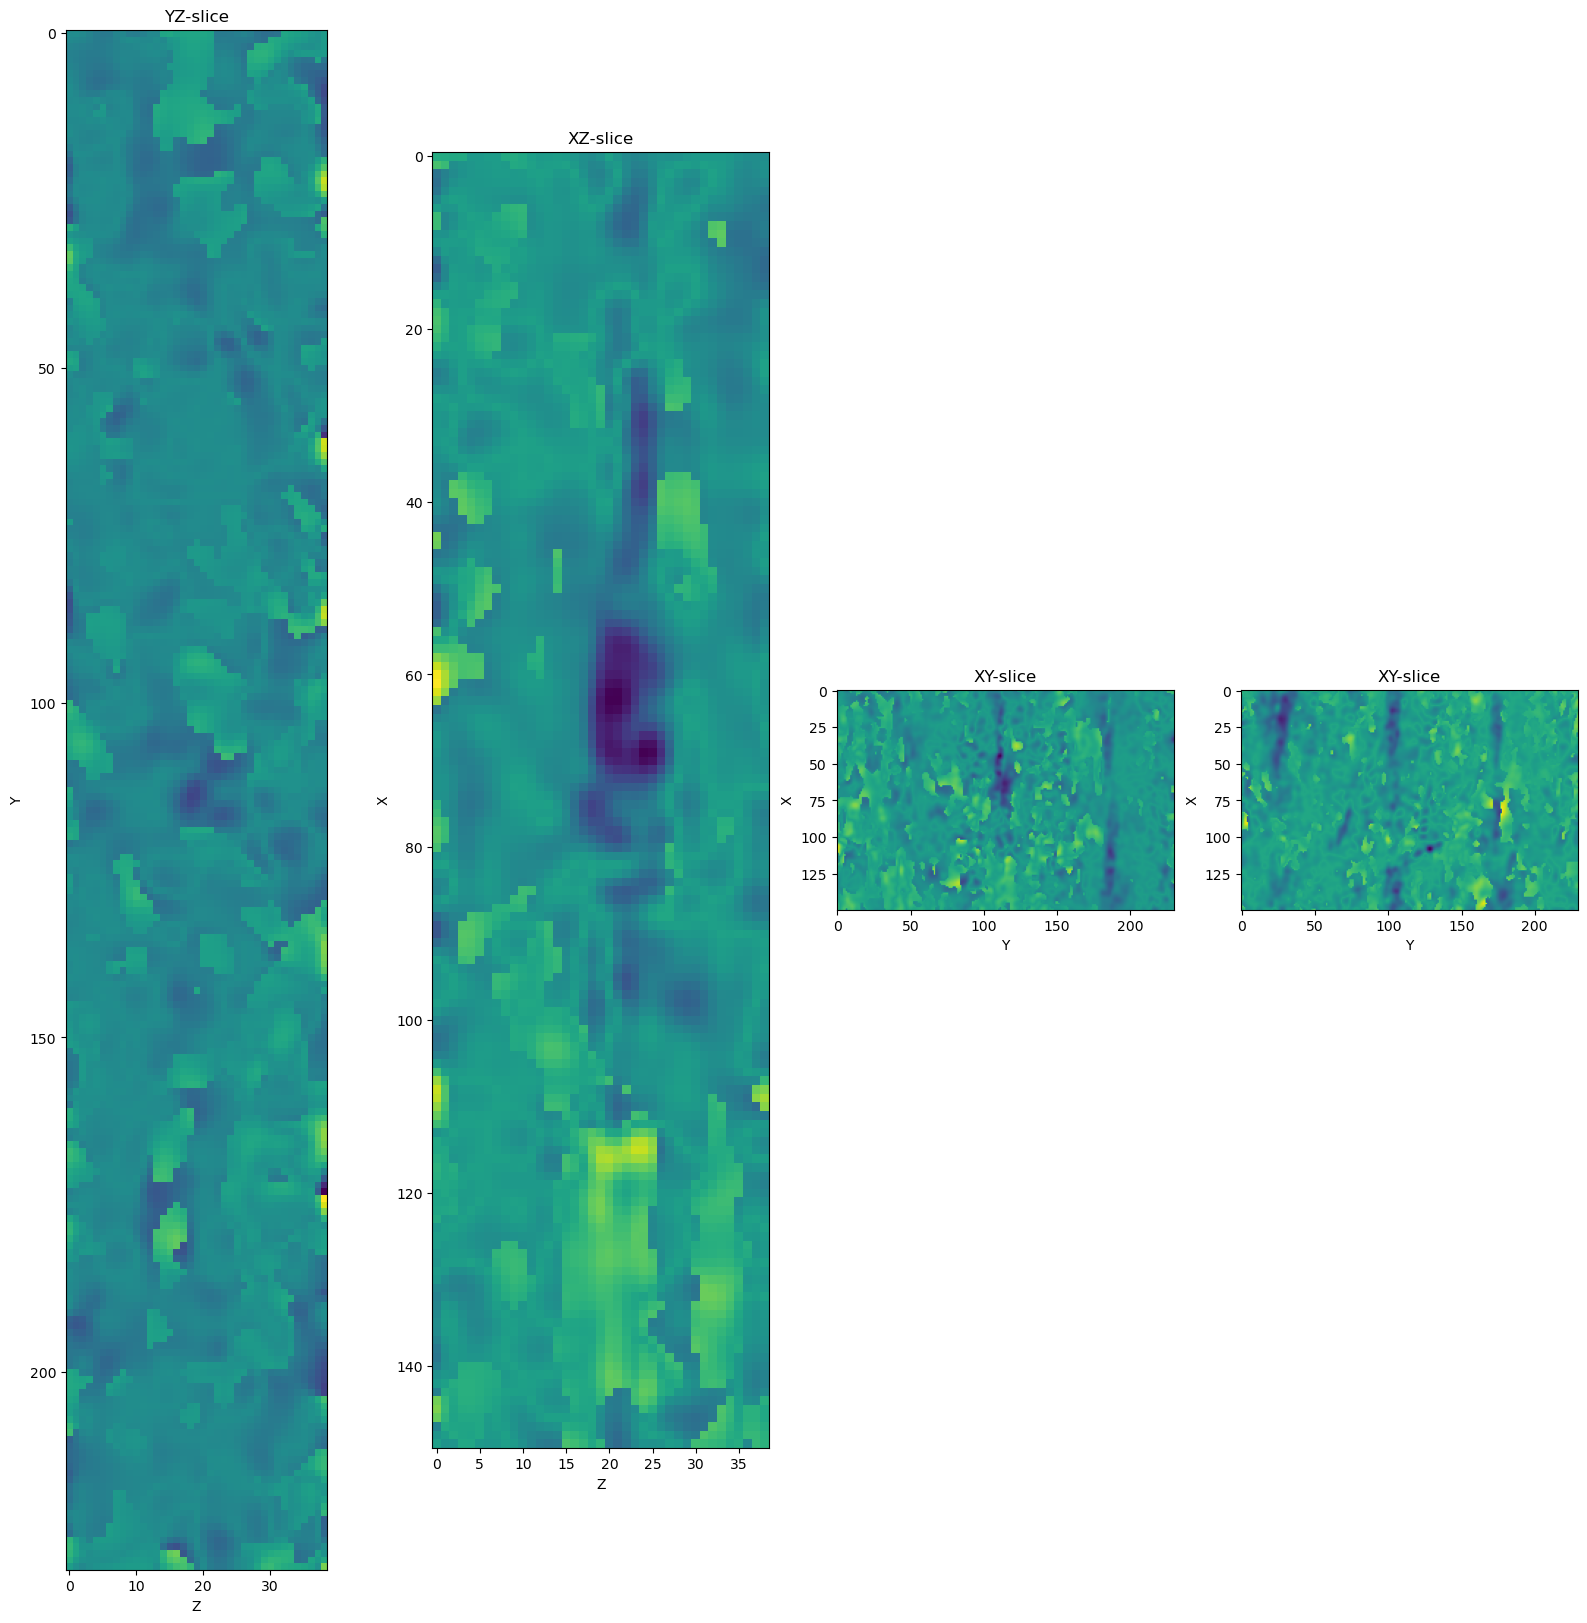

In [44]:
fig, axs = plt.subplots(1, len(data_slices), figsize=(20, 20))
for img, ax, axtil in zip(data_slices, axs, data_slices_axis):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{axtil[0]}{axtil[1]}-slice')
    ax.set_xlabel(f'{axtil[1]}')
    ax.set_ylabel(f'{axtil[0]}')
    # add_scalebar(ax, length=2, scale=voxel_size*downsample_step / 500, ticks=True)
plt.show()

fig, axs = plt.subplots(1, len(vec_slices), figsize=(20, 20))
for img, ax, axtil in zip(vec_slices, axs, data_slices_axis):
    ax.imshow(img[0])
    ax.set_title(f'{axtil[0]}{axtil[1]}-slice')
    ax.set_xlabel(f'{axtil[1]}')
    ax.set_ylabel(f'{axtil[0]}')
plt.show()

# Calculate the fiber volume fraction from the outer plane of XYZ 
Define the slice as X0 and X1 plane on YZ-Slice
Y0 and Y1 plane on XZ-Slice
Z0 and Z1 plane on XY-Slice


In [45]:
data_slices = [
    data[i].copy(),
    data[data.shape[0]-1].copy(),
    data[:, 0].copy(),
    data[:, data.shape[1]-1].copy(),
    data[:, :, 0].copy(),
    data[:, :, data.shape[2]-1].copy(),
]

vec_slices = [
    vec[:, 0].astype(np.float32),
    vec[:, vec.shape[1]-1].astype(np.float32),
    vec[:, :, 0].astype(np.float32),
    vec[:, :, vec.shape[2]-1].astype(np.float32),
    vec[:, :, :, 0].astype(np.float32),
    vec[:, :, :, vec.shape[3]-1].astype(np.float32),
]
data_slices_axis = [['Y', 'Z'],
                    ['Y', 'Z'],
                    ['X', 'Z'],
                    ['X', 'Z'], 
                    ['X', 'Y'],
                    ['X', 'Y']
                    ]

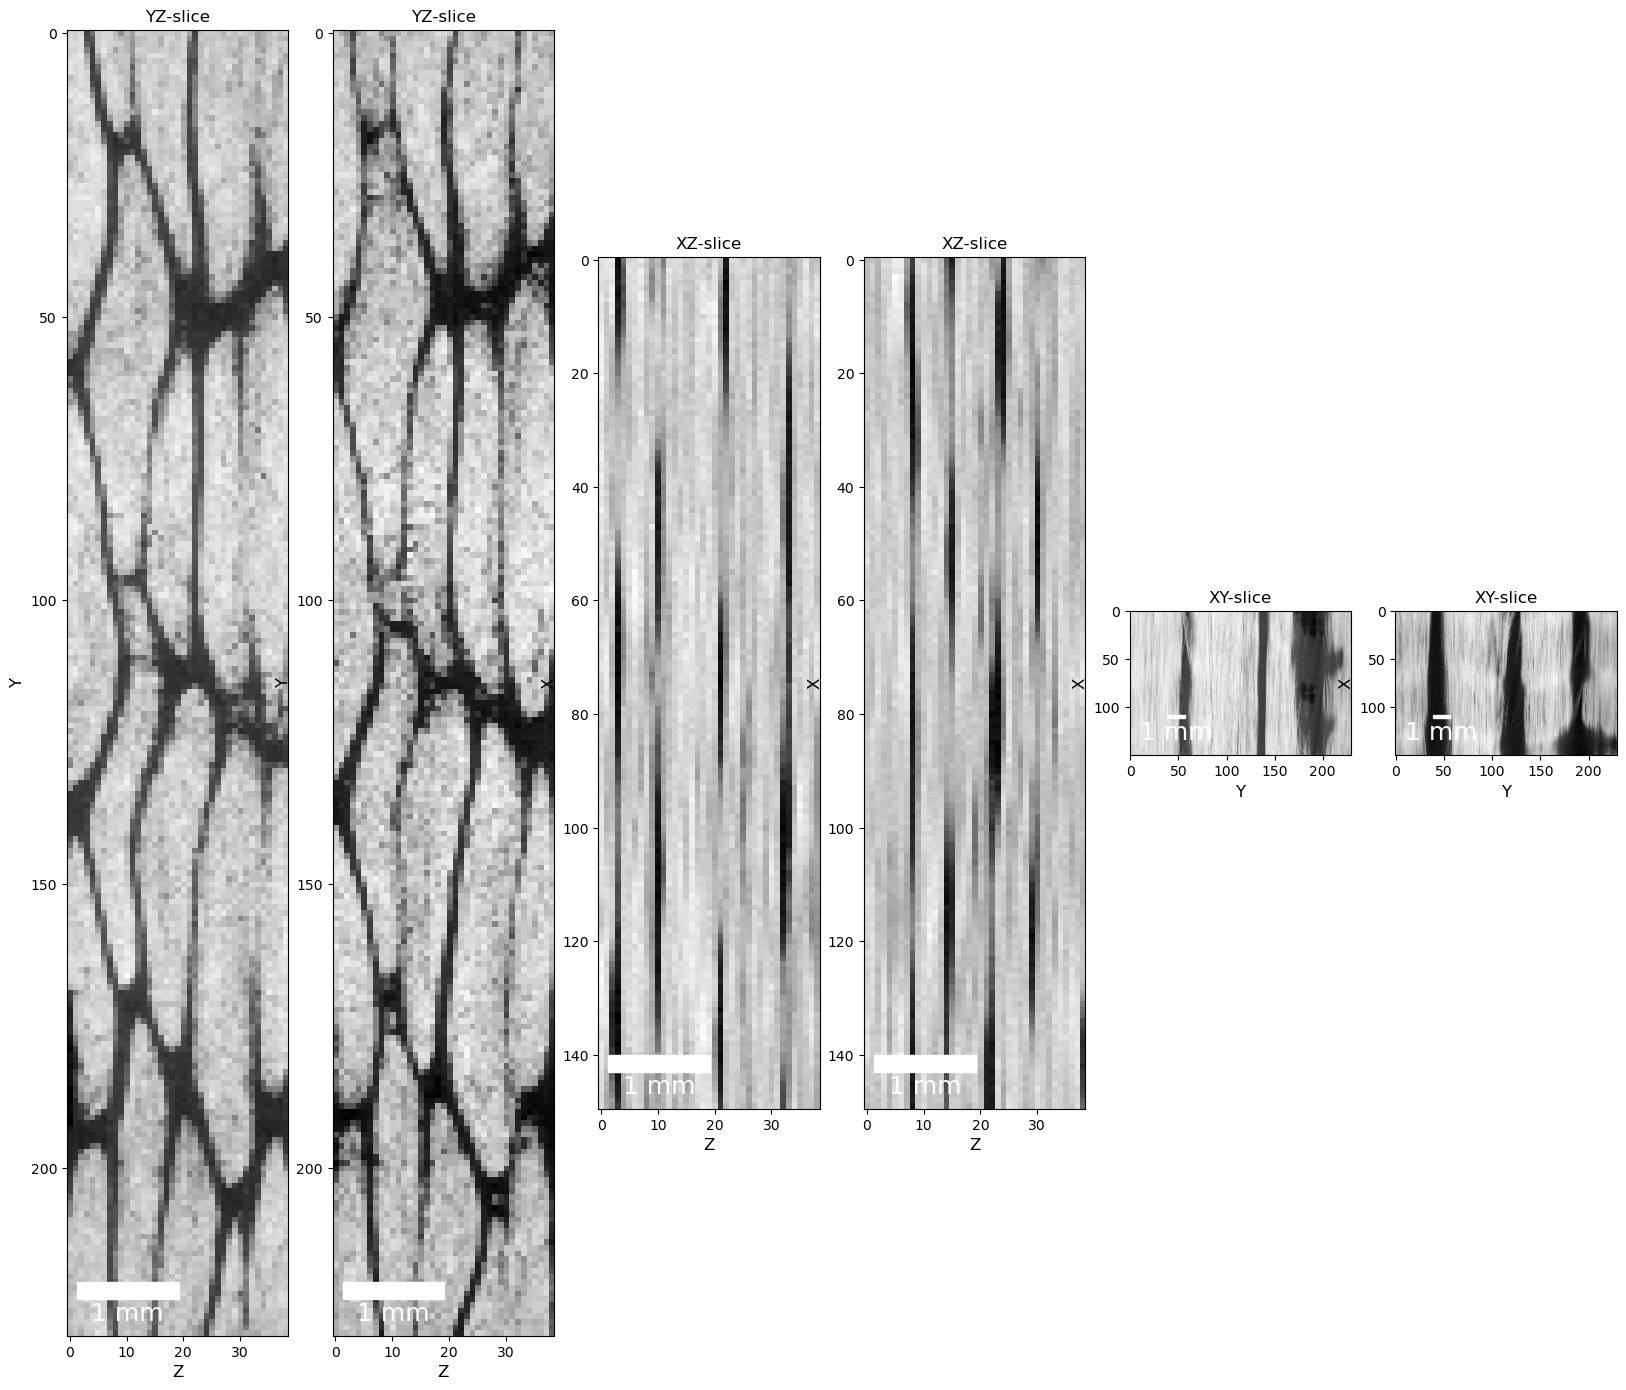

In [46]:
fig, axs = plt.subplots(1, len(data_slices), figsize=(20, 20))
for img, ax, axtil in zip(data_slices, axs, data_slices_axis):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{axtil[0]}{axtil[1]}-slice')
    ax.set_xlabel(f'{axtil[1]}',fontsize=12)
    ax.set_ylabel(f'{axtil[0]}',fontsize=12)
    add_scalebar(ax, length=1, scale=voxel_size*downsample_step / 1000, ticks=True)
plt.show()


In [47]:
i = 0
for data_slice1 in data_slices:
    dataFiber_slice1 = data_slice1 > fiber_threshold
    fiberMatrix_count_dataFiber_slice1 = np.count_nonzero(dataFiber_slice1)
    Vf_onSurface = fiberMatrix_count_dataFiber_slice1/(data_slice1.shape[0]*data_slice1.shape[1])

    print(f'Global Vf on data slice {i} surface is {Vf_onSurface} without cosidering intra fiber Vf')
    i = i +1

Global Vf on data slice 0 surface is 0.7520624303232999 without cosidering intra fiber Vf
Global Vf on data slice 1 surface is 0.7638795986622073 without cosidering intra fiber Vf
Global Vf on data slice 2 surface is 0.9128205128205128 without cosidering intra fiber Vf
Global Vf on data slice 3 surface is 0.8868376068376068 without cosidering intra fiber Vf
Global Vf on data slice 4 surface is 0.742231884057971 without cosidering intra fiber Vf
Global Vf on data slice 5 surface is 0.7193623188405797 without cosidering intra fiber Vf


## Slices with angle information
Just as we did in *StructureTensorFiberAnalysisDemo*, we can use the ```calculate_angles``` function to calculate the segmentation and orientation metrics for the slices we just read from the volumes.

First we define some plotting functions, then we calculate ```vec_class```, ```eta_os```, ```theta```, ```out_xy_angle```  and ```in_xy_angle``` for each of the slices and plot them. All the figures will be saved to the figures folder we created in the beginning. It easy to create figures for other slices simply be changing which slices are extracted from the volumes.

In [48]:
def add_scalebar(ax, length=1, scale=1, unit='mm', text=None, ticks=False):
    """Add a scale bar to the plot."""
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    text = f'{length} {unit}' if text is None else text
    
    fontprops = fm.FontProperties(size=18)
    scalebar = AnchoredSizeBar(ax.transData,
                               length / scale, text, 'lower left', 
                               pad=0.5,
                               color='white',
                               frameon=False,
                               size_vertical=3,
                               fontproperties=fontprops)
    ax.add_artist(scalebar)

def savefig(ax, i):
    title = ax.get_title()
    ax.set_title(None)
    plt.savefig(os.path.join(fig_path, f'{title}_{i}.svg'), bbox_inches='tight', pad_inches=0, dpi=300)
    plt.savefig(os.path.join(fig_path, f'{title}_{i}.pdf'), bbox_inches='tight', pad_inches=0, dpi=300)
    ax.set_title(title)

**NOTE: You can easily change which figures are made by commenting out the calls to ```fig_with_colorbar``` in the ```show_metrics``` function.** 

In [49]:
fiber_threshold

36784

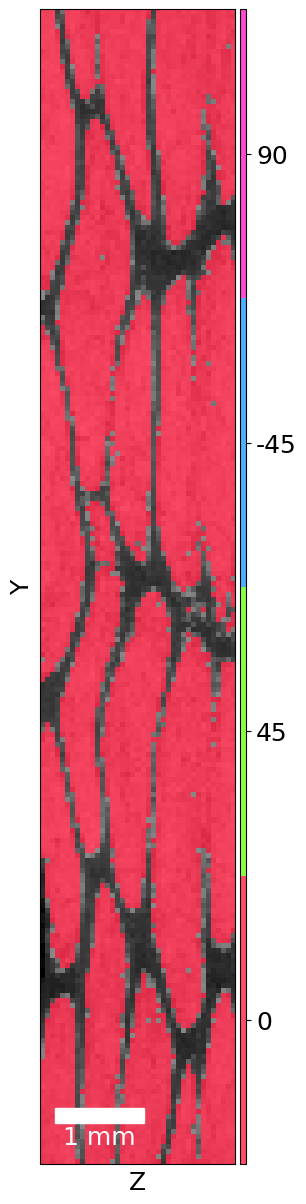

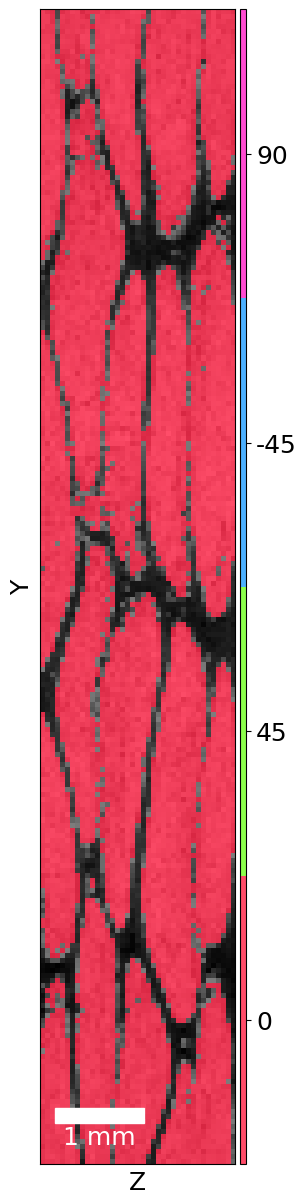

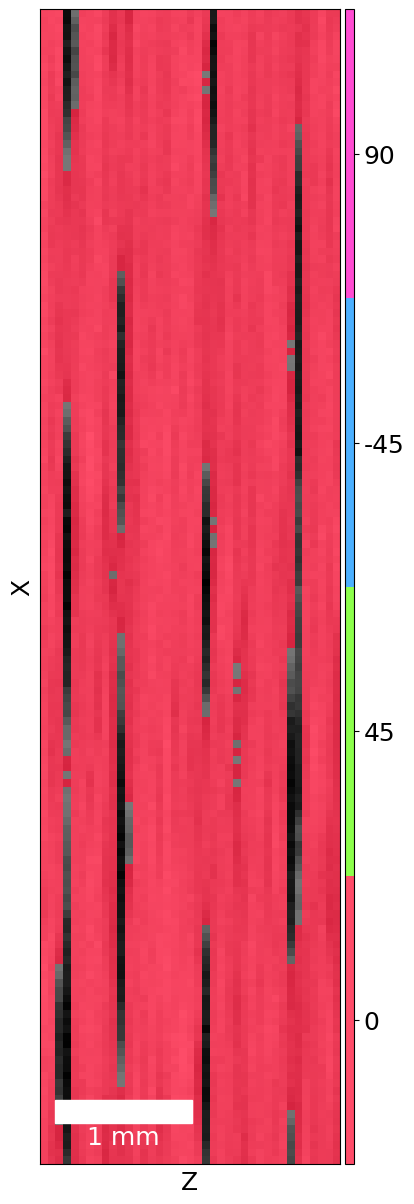

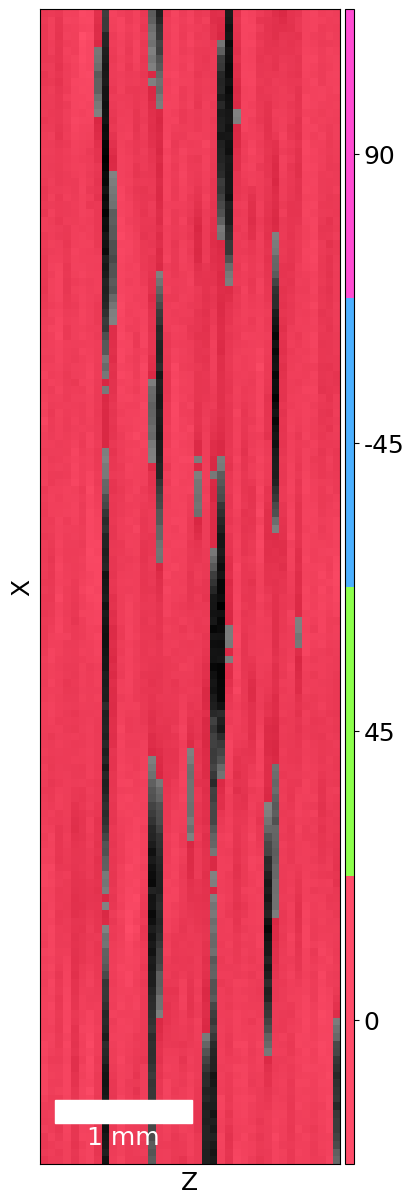

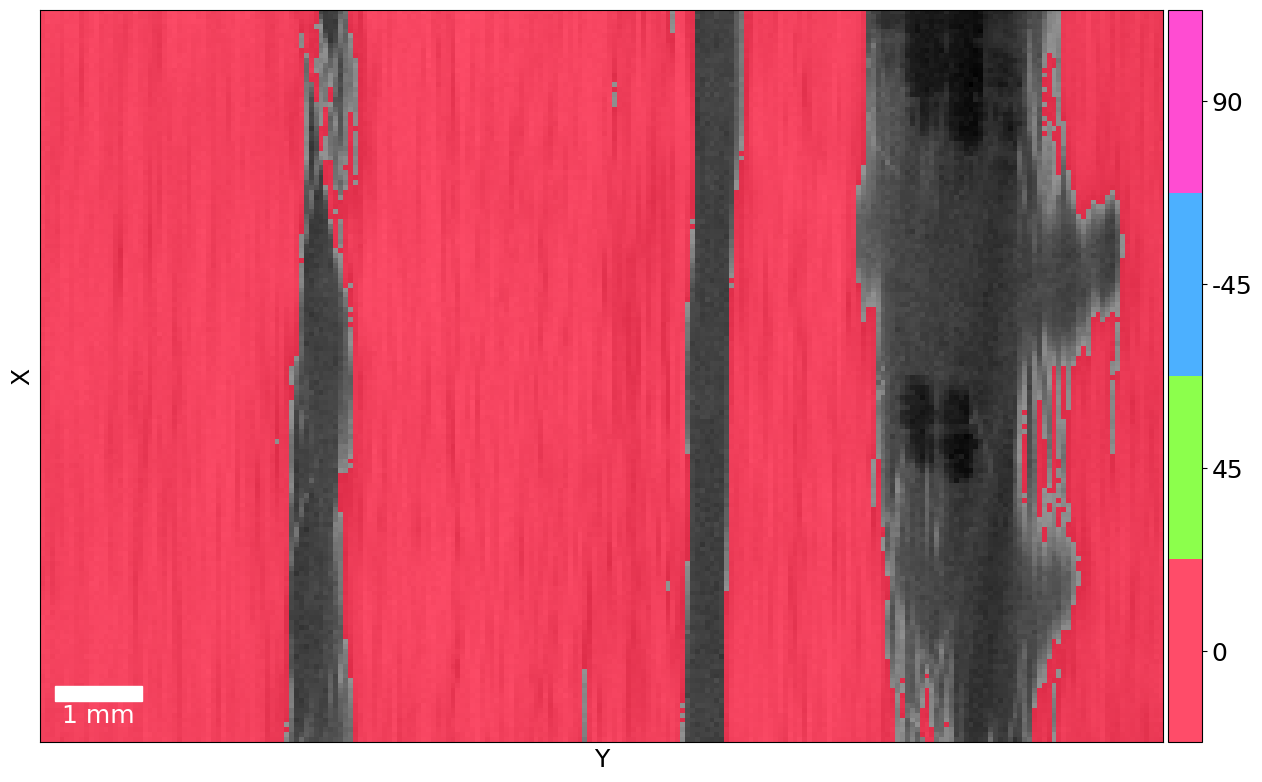

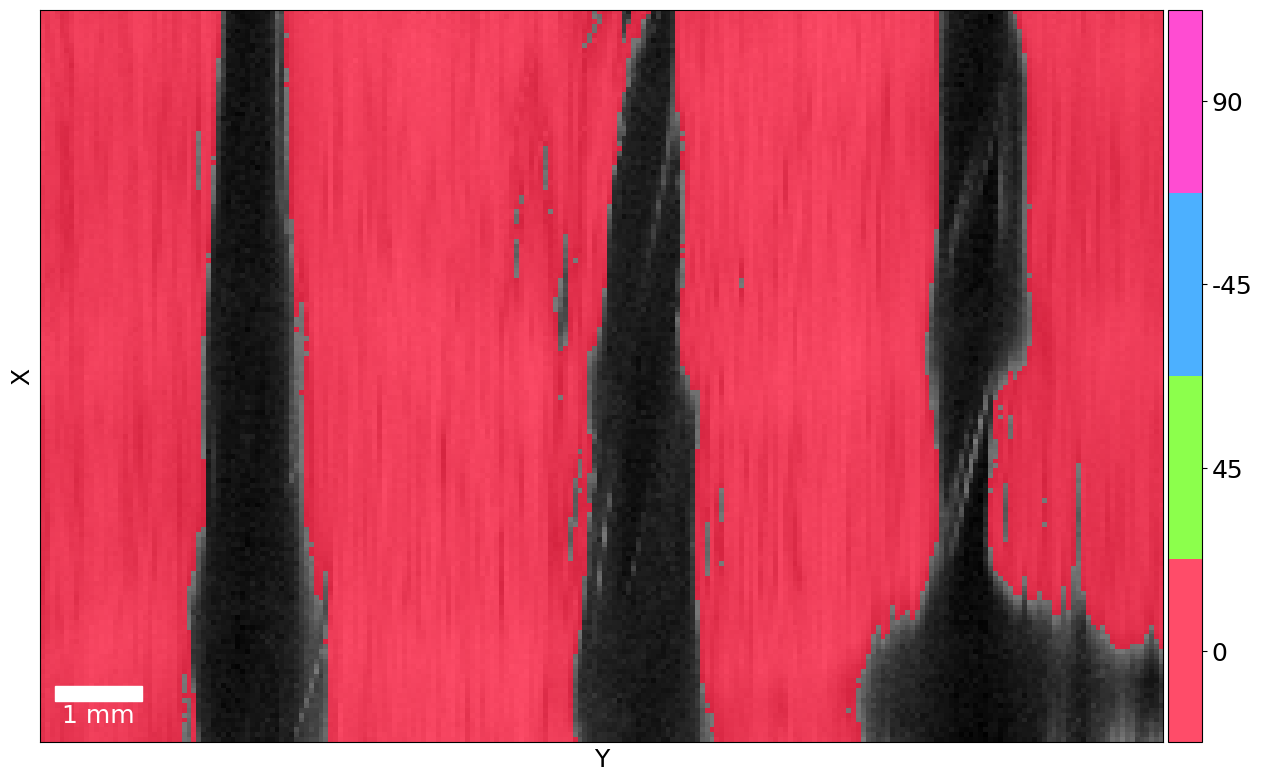

In [50]:
def fig_with_colorbar(i, d, titax, o, title, alpha=0.5, cmap=None, vmin=None, vmax=None):
    """Creates a figure with data, overlay and color bar."""
    o = o #np.rot90(o, k=-1)
    d = d #np.rot90(d, k=-1)
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    ax.imshow(d, cmap='gray')
    if np.issubdtype(o.dtype, np.integer):
        cmap = plt.get_cmap('gist_rainbow', len(class_names))
        im = ax.imshow(o, alpha=alpha, cmap=cmap, vmin=-.5, vmax=len(class_names) - .5)
        cbar = fig.colorbar(im, cax=cax, orientation='vertical', ticks=np.arange(len(class_names)))
        cbar.ax.tick_params(labelsize=18)
        cbar.ax.set_yticklabels(class_names)
    else:
        im = ax.imshow(o, alpha=alpha, cmap=cmap, vmin=vmin, vmax=vmax)
        cbar2 = fig.colorbar(im, cax=cax, orientation='vertical')
        cbar2.ax.tick_params(labelsize=18)
    # ax.set_title(title)
    # ax.set_title(f'Fiber {title} {titax[0]}{titax[1]}-slice')
    ax.set_xlabel(f'{titax[1]}', fontsize=18)
    ax.set_ylabel(f'{titax[0]}', fontsize=18)
    add_scalebar(ax, length=1, scale=voxel_size*downsample_step / 1000, text='1 mm')
    # add_scalebar(axs[2], length=2, scale=voxel_size*downsample_step / 1000, ticks=True)
    if save_figures:
        savefig(ax, i)
    plt.show()

def show_metrics(data_slices, vec_slices, fiber_threshold=None):
    
    for i, (d, v, titax) in enumerate(zip(data_slices, vec_slices, data_slices_axis)):
        vec_class, eta_os, theta, out_xy_angle, in_xy_angle = calculate_angles(v, class_vectors)

        if fiber_threshold is not None:
            fiber_mask = d <= fiber_threshold

            vec_class = np.ma.masked_where(fiber_mask, vec_class)          
            eta_os[fiber_mask] = np.nan
            theta[fiber_mask] = np.nan
            out_xy_angle[fiber_mask] = np.nan
            in_xy_angle[fiber_mask] = np.nan
        
        vec_class[vec_class>0] = 0
        
        fig_with_colorbar(i, d, titax, vec_class, 'Class', alpha=0.7)

show_metrics(data_slices, vec_slices, fiber_threshold)

### Expected domain size for the creation of Finite Element mesh

In [51]:
data_shape

(150, 230, 39)

In [52]:
downsample_step

4

In [53]:
expected_shape = [4*int(data_shape[0]/4), 4*int(data_shape[1]/4), 4*int(data_shape[-1]/4)]  ##### This has been done to make sure the domain dimension is within the data_shape
# expected_shape = [640/downsample_step, 640/downsample_step, data_shape[-1]-3] ##### For skipp vox 4 , UD
print('The expected shape has been divided into 4x4x4 blocks with size xblk, yblk, zblk')

The expected shape has been divided into 4x4x4 blocks with size xblk, yblk, zblk


In [54]:
expected_shape

[148, 228, 36]

In [55]:
fiber_threshold

36784

#### Create folder to organize all block domains into specific directories named after the corresponding slices. This is ncessary to mention because the rest of the code will run in linux environment.

In [60]:
# File location for Windows machine

path_wd = "C:/Users/debaa/Desktop/SoftwareXPaperGitHub/Permeability"

# File location for Linux machine used in writing json file.
path_unix = "/mnt/c/Users/debaa/Desktop/SoftwareXPaperGitHub/Permeability"

#### Created two empty file of constant and system into the SLICE_*Z* file of each block. This will be filled with blockMesh and porosityProperties in the end by MATLAB script after creation of Finite Element mesh from DREAM3D

In [62]:
def dream3D_multidoaminSlice(data_slices, vec_slices, fiber_threshold=None):

    
    # Write the data file into dream3D image
    # Doamin size will be something like (500,250,100)
    # Doamin1 is reduced to (100,50,50)

    xblk = int(expected_shape[0]/4)
    yblk = int(expected_shape[1]/4)
    zblk = int(expected_shape[2]/4)
        
    xspace = downsample_step
    yspace = downsample_step
    zspace = downsample_step

    orgx = 0
    orgy = 0
    orgz = 0

    sln = 0 # Slice number counter in each layers

    for slz in range(4):
        zstr = zblk*slz
        zend = zblk*(slz+1) 
        orgz= zstr + zblk*(zspace-1)*(slz)
        print(f'I am shifing the y origin by{orgz}')
        

        sln = 0
        for sly in range(4):
            ystr = yblk*sly     
            yend = yblk*(sly+1)
            # if (sly > 0):
            orgy= ystr + yblk*(yspace-1)*(sly)

            print(f'I am shifing the y origin by{orgy}')
        
            for slx in range(4):
                xstr = xblk*slx   
                xend = xblk*(slx+1)
                orgx= xstr + xblk*(xspace-1)*(slx)

                print(f'I am shifing the y origin by{orgy}')

                sln = sln + 1

                SLICE_File = path_wd+f'/Dom{int(expected_shape[0])}x{int(expected_shape[1])}x{int(expected_shape[2])}/Thresold'+str(fiber_threshold)+'skippVox'+str(downsample_step)+'/SLICE_'+str(sln)+'Z'+str(slz+1)

                if str(os.path.exists(SLICE_File)) == "True":
                    print("SLICE FILE file exists")
                    shutil.rmtree(SLICE_File, ignore_errors=True)

                pathlib.Path(SLICE_File ).mkdir(parents=True, exist_ok=True) 
                pathlib.Path(SLICE_File +'/constant' ).mkdir(parents=True, exist_ok=True)
                pathlib.Path(SLICE_File +'/system' ).mkdir(parents=True, exist_ok=True) 

                # Create a dummy data file of each slices now. 
                # Leter this is coppied to individual data file in each slice.
                src =  path_wd+f'/Dom{int(expected_shape[0])}x{int(expected_shape[1])}x{int(expected_shape[2])}/Thresold'+str(fiber_threshold)+'skippVox'+str(downsample_step)+'/' + f'dream3D_data_angle_matrix_{xblk}x{yblk}x{zblk}.txt'
                dream3d_class = open(src, "w+")
                
                xx = 0
                for i in range(xstr, xend):
                    xx = xx + 1
                    vec_class, eta_os, theta, out_xy_angle, in_xy_angle = calculate_angles(vec[:,i].astype(np.float32), class_vectors)
                    d = data[i].copy()
                            
                    if fiber_threshold is not None:
                        fiber_mask = d <= fiber_threshold
                            
                        vec_class = np.ma.masked_where(fiber_mask, vec_class)          
                        eta_os[fiber_mask] = np.nan
                        theta[fiber_mask] = np.nan
                        out_xy_angle[fiber_mask] = np.nan
                        in_xy_angle[fiber_mask] = np.nan

                        # print(fiber_mask)  

                    ####  Deifining the other fiber class +-45 and 90 to 0 since this is an UD fiber layups
                    vec_class[vec_class>0] = 0
                    
                    # if i == xend:
                    #     fig_with_colorbar(d, vec_class, 'Class', alpha=0.7)
                    #     fig_with_colorbar(d, eta_os, '$\eta_O$(X)', alpha=0.5, vmin=0, vmax=1)
                    #     fig_with_colorbar(d, theta, 'Angle from X (0-90 deg.)', alpha=0.5, vmin=0, vmax=90)
                    #     fig_with_colorbar(d, in_xy_angle, 'In-plane orientation (-90-90 deg.)', cmap='bwr', alpha=0.5, vmin=-90, vmax=90)
                    #     fig_with_colorbar(d, out_xy_angle, 'Out-of-plane orientation (-90-90 deg.)', cmap='bwr', alpha=0.5, vmin=-90, vmax=90)
                    #     fig_with_colorbar(d, theta, 'Angle from X (0-10 deg.)', alpha=0.5, vmin=0, vmax=10)
                    #     fig_with_colorbar(d, in_xy_angle, 'In-plane orientation (-10-10 deg.)', cmap='bwr', alpha=0.5, vmin=-10, vmax=10)
                    #     fig_with_colorbar(d, out_xy_angle, 'Out-of-plane orientation (-10-10 deg.)', cmap='bwr', alpha=0.5, vmin=-10, vmax=10)

                    # for k in range(1):
                    yy = 0
                    for y in range(ystr, yend):
                        yy = yy + 1

                        zz = 0
                        for z in range(zstr, zend):
                            zz = zz + 1
                            if str(vec_class[y,z]) == '--':
                                dream3d_class.write(str(4)+'\n')
                            else:
                                dream3d_class.write(str(vec_class[y,z])+'\n')
         

                dream3d_class.close()
                

                # orientation in deam3d shows oposite in (zz, yy, xx))
                dimns = np.array([zz, yy, xx])
                print(dimns)

                
                
                origin = np.array([orgz, orgy, orgx])
                print(origin)
                
                spacing = np.array([zspace, yspace, xspace])

                dst = f'dream3D_data_angle_matrix_{xblk}x{yblk}x{zblk}.txt'

                Fdst = path_wd+f'/Dom{int(expected_shape[0])}x{int(expected_shape[1])}x{int(expected_shape[2])}/Thresold'+str(fiber_threshold)+'skippVox'+str(downsample_step)+'/'+'SLICE_'+str(sln)+'Z'+str(slz+1)+f'/dream3D_data_angle_matrix_{xblk}x{yblk}x{zblk}.txt'

                # print('source', src)
                # print('destination ',Fdst)
                # shutil.copyfile(src, Fdst)

                try:
                    shutil.copyfile(src, Fdst)
                    print("copy the slice files")
                except:
                    print("same slice file already exists")

                # This has been redefined as the dream3d pipeline run in linux machine
                SLICE_File_unix = path_unix + f'/Dom{int(expected_shape[0])}x{int(expected_shape[1])}x{int(expected_shape[2])}/Thresold'+str(fiber_threshold)+'skippVox'+str(downsample_step)+'/SLICE_'+str(sln)+'Z'+str(slz+1)
                Fdst_unix = SLICE_File_unix + '/'+ dst
    
                # Keep the updated JSON file for each slice using Windows system directory system
                path_Write_wd = path_wd + f'/Dom{int(expected_shape[0])}x{int(expected_shape[1])}x{int(expected_shape[2])}/Thresold'+str(fiber_threshold)+'skippVox'+str(downsample_step)+'/SLICE_'+str(sln)+'Z'+str(slz+1)
                # dream3d_default_WD = path_wd + '/dream3D_pipeline' 
                # Create the DREAM3D json file for the abaqus mesh generation
                jesonDream3d(path_wd, path_Write_wd, dimns, origin, spacing, Fdst_unix, sln, slz, SLICE_File_unix)

                print('slice_'+str(sln)+'Z'+str(slz+1)+' josn file written.')
                # sys.exit()

dream3D_multidoaminSlice(data_slices, vec_slices, fiber_threshold)

I am shifing the y origin by0
I am shifing the y origin by0
I am shifing the y origin by0
[ 9 57 37]
[0 0 0]
copy the slice files
slice_1Z1 josn file written.
I am shifing the y origin by0
[ 9 57 37]
[  0   0 148]
copy the slice files
slice_2Z1 josn file written.
I am shifing the y origin by0
[ 9 57 37]
[  0   0 296]
copy the slice files
slice_3Z1 josn file written.
I am shifing the y origin by0
[ 9 57 37]
[  0   0 444]
copy the slice files
slice_4Z1 josn file written.
I am shifing the y origin by228
I am shifing the y origin by228
[ 9 57 37]
[  0 228   0]
copy the slice files
slice_5Z1 josn file written.
I am shifing the y origin by228
[ 9 57 37]
[  0 228 148]
copy the slice files
slice_6Z1 josn file written.
I am shifing the y origin by228
[ 9 57 37]
[  0 228 296]
copy the slice files
slice_7Z1 josn file written.
I am shifing the y origin by228
[ 9 57 37]
[  0 228 444]
copy the slice files
slice_8Z1 josn file written.
I am shifing the y origin by456
I am shifing the y origin by456
[ 